# FIP 05 — DA × NE: RPE coding, phasic coupling, tonic coupling, and dissociation

Dopamine (dLight, lateral NAc) and LC-NE axon calcium (GCaMP in LC axons, imaged in PL) recorded
together during dynamic foraging. The notebook asks five questions, each building on the one
before it:

1. **Does each signal carry a reward prediction error?** Comparing "the DA and NE RPE signals"
   presupposes both have one, and the comparison depends on what form each takes (signed RPE,
   reward only, or unsigned surprise).
2. **Do outcome responses covary trial by trial?** A DA–NE correlation across trials can come
   from both signals responding to outcome and RPE, or from trial-to-trial variability the two
   share beyond outcome and RPE. The second is the correlation of the residuals after outcome and
   RPE; response time, trial position and pre-cue baseline are each tested separately as a
   control on it. How alike the two signals' outcome and RPE tuning is belongs to question 1 and
   is compared there.
3. **Do phasic events line up in timing and magnitude?** First for the task-locked response, then
   for every large transient in the session, including those outside the outcome window.
4. **Do tonic levels covary, and on which timescales?** Pre-trial baselines, their relation to
   value, and the DA–NE correlation resolved by timescale, raw and with task-evoked responses
   removed.
5. **How often does one have a large transient without the other?** Measured against chance, as a
   function of transient size, and by task context.

Sections 1–5 answer these in order (section 0 loads the data, section 6 collects the numbers).
Sections 1–2 concern the outcome response; 3 extends to all transients; 4 goes to slower
timescales; 5 is what remains after the shared part is measured.

**Signals.** "NE" is GCaMP in LC noradrenergic axons (FLEX GCaMP in LC of DBH-Cre mice), measured
in prelimbic cortex. It is axonal calcium, not transmitter release. "DA" is extracellular dopamine
(dLight) in lateral NAc. The two indicators have different kinetics, so a latency difference
between signals mixes indicator and transmitter timing.

**Data.** Two FIP assets built by Rachel's grouped analysis wrapper, both curated when built and in
the same per-session parquet layout (`df_fip`, `df_trials`, `df_events`). Signals are
`dff-bright_mc-iso-IRLS` dF/F at 20 Hz on the session clock (0 = first go cue).

**Unit of inference.** Every pair is DA and NE from the same hemisphere, and each animal is held
to one hemisphere. Measures are averaged within session, then within animal; error bars are SEM
over animals and tests are Wilcoxon signed-rank on animal means (smallest attainable two-sided p
with 9 animals is 0.004).

## Setup

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

import fip_coupling as fc
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

# Each asset: the first candidate path that holds df_curation_*.csv is used (the loader also looks
# one level down in data/). The 4-channel asset is the 2026-09-22 CSV-curated rebuild; on Code
# Ocean it must be attached under the first name below for this notebook to find it.
ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
CACHE_PATH = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
              else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Session inclusion ────────────────────────────────────────────────────────
FS = 20.0                    # Hz, grid rate
MIN_SESSIONS_PER_ANIMAL = 3  # same-side sessions an animal needs to be included
MIN_RPE_SD = 0.05            # within-outcome RPE SD a session needs for RPE slopes (2 sessions fall at ~0.01)

# ── Per-trial windows (s) ────────────────────────────────────────────────────
BASELINE_WIN = (-1.0, 0.0)   # relative to the go cue; the tonic level entering the trial
RESP_WINS = {                # relative to the outcome, baseline-subtracted
    "early": (0.0, 0.5),     # the initial transient, present on every responded trial
    "late": (0.5, 2.0),      # where rewarded and unrewarded diverge (DA dip on omission)
    "full": (0.0, 2.0),
}
LATENCY_WIN = (0.0, 1.5)     # peak search window after the go cue

# ── Continuous-signal model ──────────────────────────────────────────────────
KERNEL_S = (-1.0, 4.0)       # FIR kernel span around cue / outcome / lick
BANDS = [(1 / 600, 1 / 120), (1 / 120, 1 / 30), (1 / 30, 1 / 8), (1 / 8, 0.5), (0.5, 2.0)]
BAND_NAMES = ["2–10 min", "30 s–2 min", "8–30 s", "2–8 s", "0.5–2 s"]
N_NULL = 200                 # circular shifts per session
MIN_SHIFT_S = 120.0          # smallest circular shift for the band null

# ── Transients ───────────────────────────────────────────────────────────────
LARGE_PROM = 2.0             # z prominence that makes a transient "large"
PARTNER_PROM = 1.0           # z prominence that counts as a partner in the other signal
MATCH_WIN_S = 0.5            # partner must peak within this many s
PROM_SWEEP = [1.5, 2.0, 2.5, 3.0]

SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"]}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)"}
rng = np.random.default_rng(0)

## 0. Data: pair DA with NE by hemisphere

`fc.inventory_pairs` finds every session with a lateral-NAc DA fiber and a PL NE fiber on the same
side. Each animal then contributes one side, whichever has more sessions, so side never varies
within an animal. `medNAcc` DA fibers are left out to keep one DA site throughout.

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fc.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fc.inventory_pairs(asset_roots)
kept, side_table = fc.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
print(f"\n{len(inv)} same-side pairs found; {len(kept)} sessions from "
      f"{kept.subject.nunique()} animals kept")
side_table

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data



103 same-side pairs found; 97 sessions from 9 animals kept


side,asset,L,R,side_used,n_used,kept
subject,,,,,,
800886,3ch,5,0,L,5,True
808054,4ch,1,16,R,16,True
809487,4ch,8,0,L,8,True
809491,4ch,20,0,L,20,True
815334,4ch,3,4,R,4,True
816212,4ch,8,0,L,8,True
816214,4ch,0,5,R,5,True
818585,3ch,8,0,L,8,True
818586,3ch,23,0,L,23,True


In [4]:
pairs = fc.load_pairs(kept, fs=FS, cache_path=CACHE_PATH)
n_min = np.array([len(p["da"]) / FS / 60 for p in pairs])
print(f"{len(pairs)} sessions, median task period {np.median(n_min):.1f} min "
      f"(range {n_min.min():.0f}–{n_min.max():.0f})")
SUBJECTS = sorted({p["subject"] for p in pairs})
N_ANIMALS = len(SUBJECTS)

loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl
97 sessions, median task period 75.2 min (range 30–75)


### Per-trial table

`fc.trial_measures` z-scores each signal over its session, then per trial takes the pre-cue
baseline, outcome responses in each `RESP_WINS` window (baseline-subtracted), and the latency and
height of the peak after the go cue. Response time here is short (median ≈0.2 s), so cue, first
lick and outcome responses overlap; the outcome windows start at the outcome and capture all three.

Two sessions (816212_2025-12-10, 818586_2026-01-05) are dropped from `resp`, and so from the RPE
regressions, trial coupling and latency analyses (the PETHs and section 4 still include them): their Q-learning fit has Q_chosen ≈ 0 throughout, so RPE varies by about 0.01 within each
outcome (every other session ≥ 0.06) and RPE slopes fitted there reach ±10–16.

In [5]:
trials = pd.concat([fc.trial_measures(p, RESP_WINS, BASELINE_WIN, LATENCY_WIN) for p in pairs],
                   ignore_index=True)
RPE_COL = "RPE_earned"  # Rachel's convention; RPE_all adds unearned (extra) water
# Low-value choices are slower (Q_chosen vs RT r = -0.05 to -0.43 per animal), so outcome-aligned
# windows hold more of the cue response on low-value trials; RT and session position are nuisance terms.
RPE_NUISANCE = ["response_time", "trial_frac"]
extra = trials["responded"] & trials["extra_reward"].astype(bool)
resp = trials[trials["responded"] & ~extra].dropna(subset=[RPE_COL, "da_full", "ne_full"]).copy()
# Sessions whose Q-learning fit leaves RPE almost constant within each outcome (Q_chosen ≈ 0 on every
# trial) cannot support an RPE slope; their coefficients run to ±10 and above.
rpe_sd = resp.groupby(["session", "rewarded"])[RPE_COL].std().unstack().min(axis=1)
flat_rpe = rpe_sd.index[rpe_sd < MIN_RPE_SD]
resp = resp[~resp["session"].isin(flat_rpe)].copy()
print(f"excluded for flat RPE (within-outcome SD < {MIN_RPE_SD}): "
      + ", ".join(f"{s} ({rpe_sd[s]:.3f})" for s in flat_rpe))
resp["rpe_x_rew"] = resp[RPE_COL] * resp["rewarded"]
resp["rpe_x_unrew"] = resp[RPE_COL] * (~resp["rewarded"])
print(f"{len(trials)} trials; {extra.sum()} responded trials with extra (unearned) water excluded; "
      f"{len(resp)} responded trials with an RPE estimate")
print("median response time: %.2f s" % resp["response_time"].median())

excluded for flat RPE (within-outcome SD < 0.05): 816212_2025-12-10 (0.014), 818586_2026-01-05 (0.009)
48635 trials; 393 responded trials with extra (unearned) water excluded; 42946 responded trials with an RPE estimate
median response time: 0.20 s


In [6]:
def animal_strip(ax, df, cols, labels, colors, ylabel, title=None, connect=True, zero=True):
    '''Per-animal points for several measures, with the mean over animals as a bar.

    df is indexed by subject with one column per measure; lines join one animal's points.'''
    x = np.arange(len(cols))
    if connect:
        for _, row in df[cols].iterrows():
            ax.plot(x, row.values, color="0.8", lw=0.8, zorder=1)
    for k, c in enumerate(cols):
        v = df[c].to_numpy(float)
        jitter = (rng.random(len(v)) - 0.5) * 0.15
        ax.scatter(x[k] + jitter, v, s=18, color=colors[k], zorder=2, edgecolor="none")
        m, p, n = fc.wilcoxon_animals(v)
        ax.plot([x[k] - 0.25, x[k] + 0.25], [m, m], color="k", lw=2, zorder=3)
        star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        ax.text(x[k], 1.02, star, transform=ax.get_xaxis_transform(), ha="center", fontsize=8)
    if zero:
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, loc="left", pad=16)
    style_ax(ax)


def grand_trace(ax, mats_by_animal, lags, color, label, ls="-"):
    '''Mean ± SEM over animals of per-animal mean traces.'''
    A = np.stack(mats_by_animal)
    m = np.nanmean(A, 0)
    se = np.nanstd(A, 0) / np.sqrt(np.isfinite(A).all(1).sum())
    ax.plot(lags, m, color=color, label=label, ls=ls)
    ax.fill_between(lags, m - se, m + se, color=color, alpha=0.2, lw=0)


def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."


def sess_corr(g, a, b):
    """Pearson r of two columns across the rows of g (NaN with 10 or fewer complete rows)."""
    d = g[[a, b]].dropna()
    return np.corrcoef(d[a], d[b])[0, 1] if len(d) > 10 else np.nan

### Example session

Two minutes of both z-scored traces with go cues and outcomes marked, to show what the rest of
the notebook measures.

example session: 818586_2026-01-16


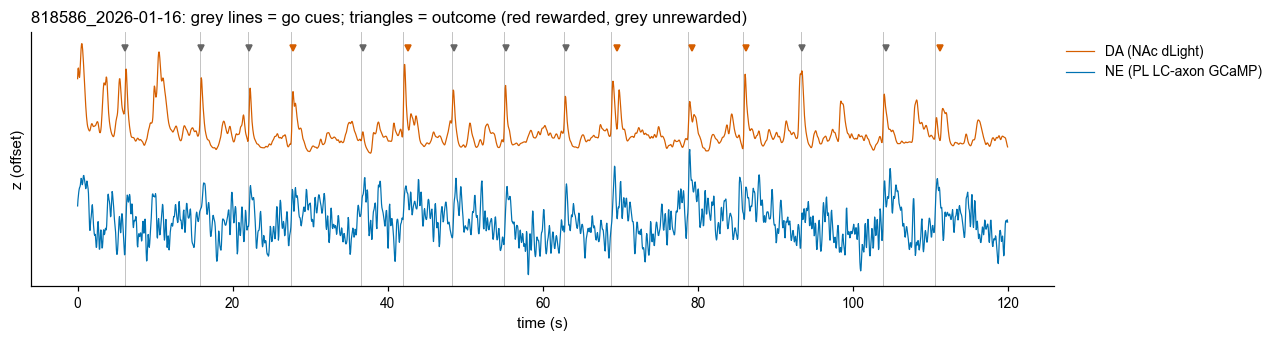

In [7]:
EXAMPLE_SESSION = None  # None: the 818586 session with the most trials; or a session id string
if EXAMPLE_SESSION is None:
    cand = [p for p in pairs if p["subject"] == "818586"] or pairs
    ex = max(cand, key=lambda p: len(p["trials"]))
else:
    ex = next(p for p in pairs if p["session"] == EXAMPLE_SESSION)
print("example session:", ex["session"])

t_ex = ex["t0"] + np.arange(len(ex["da"])) / FS
w0 = 1200.0
sel = (t_ex >= w0) & (t_ex < w0 + 120)
fig, ax = plt.subplots(figsize=(12, 3))
for sig, off in (("da", 0), ("ne", -5)):
    ax.plot(t_ex[sel] - w0, fc.zscore(ex[sig])[sel] + off, color=SIG_COLOR[sig], lw=0.8,
            label=SIG_LABEL[sig])
tr = ex["trials"]
for _, r in tr.iterrows():
    tc = r["goCue_start_time_in_session"]
    if w0 <= tc < w0 + 120:
        ax.axvline(tc - w0, color="0.75", lw=0.6, zorder=0)
        if r["animal_response"] < 2:
            ax.plot(r["reward_outcome_time_in_session"] - w0, 4.5, "v", ms=4,
                    color=PALETTE["pos"] if r["earned_reward"] else "0.4")
ax.set_xlabel("time (s)")
ax.set_ylabel("z (offset)")
ax.set_yticks([])
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set_title(f"{ex['session']}: grey lines = go cues; triangles = outcome "
             "(red rewarded, grey unrewarded)", loc="left")
style_ax(ax)
save_fig(fig, "fip_05_example_traces", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 1. Does each signal carry an RPE?

Outcome-aligned averages for rewarded and unrewarded trials, then split by RPE within each outcome.
RPE is `RPE_earned` = earned reward − Q_chosen, from the per-session fit of
`QLearning_L1F1_CK1_softmax` (AIND analysis-architecture pipeline), attached to `df_trials` by
`aind_dynamic_foraging_data_utils.enrich_dfs.enrich_df_trials_fm` in Rachel's wrapper. This is the
column Rachel's own RPE binning (`rachel_analysis_utils.analysis_utils.enrich_df_trials`) uses.
`RPE_all` also counts extra (unearned) water; the ~1% of responded trials with extra water are
excluded here, since their outcome response mixes in water that the earned/unearned split does not
describe. Within an outcome class, RPE is set by the chosen value: 1 − Q_chosen after a
reward, −Q_chosen after an omission. A signed-RPE signal scales positively with RPE in *both*
classes. A pure outcome signal does not scale within a class. An unsigned surprise signal scales
positively for rewards and negatively for omissions.

`fc.fit_rpe_terms` fits `response ~ reward + RPE·rewarded + RPE·unrewarded + RT + trial position`
per session, and the coefficients are averaged within animal. Response time is a nuisance term
because low-value choices are slower, so a window aligned to the outcome holds more of the cue
response on low-value trials.

In [8]:
LAGS = np.arange(-2.0, 4.0 + 1e-9, 1 / FS)
N_RPE_BINS = 3

peth = {}   # (sig, key) -> list of per-animal mean traces
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        tr = p["trials"]
        responded = (tr["animal_response"] < 2).to_numpy()
        rewarded = tr["earned_reward"].astype(bool).to_numpy() & responded
        out = tr["reward_outcome_time_in_session"].to_numpy()
        cue = tr["goCue_start_time_in_session"].to_numpy()
        rpe = tr[RPE_COL].to_numpy()
        rpe[tr["extra_reward"].astype(bool).to_numpy()] = np.nan  # extra-water trials out of the RPE split
        groups = {"rewarded": (out, rewarded), "unrewarded": (out, responded & ~rewarded),
                  "ignored (cue)": (cue, ~responded)}
        for cls, m_cls in (("rew", rewarded), ("unrew", responded & ~rewarded)):
            v = rpe[m_cls & np.isfinite(rpe)]
            if len(v) < 3 * N_RPE_BINS:
                continue
            edges = np.quantile(v, np.linspace(0, 1, N_RPE_BINS + 1))
            b = np.digitize(rpe, edges[1:-1])
            for k in range(N_RPE_BINS):
                groups[f"{cls} RPE{k}"] = (out, m_cls & np.isfinite(rpe) & (b == k))
        for sig in ("da", "ne"):
            z = fc.zscore(p[sig])
            pre = fc.window_mean(z, p["t0"], FS, cue, *BASELINE_WIN)
            for key, (times, m) in groups.items():
                if m.sum() >= 3:
                    seg = fc.peri_event(z, p["t0"], FS, times[m], LAGS)
                    if "RPE" in key:  # tercile panels: per-trial pre-cue baseline removed, as in the regression
                        seg = seg - pre[m][:, None]
                    acc.setdefault((sig, key), []).append(np.nanmean(seg, 0))
    for k, v in acc.items():
        peth.setdefault(k, []).append(np.mean(v, 0))

In [9]:
rpe_terms = []
for (subj, sess), g in resp.groupby(["subject", "session"]):
    for sig in ("da", "ne"):
        for w in RESP_WINS:
            s = fc.fit_rpe_terms(g, f"{sig}_{w}", RPE_COL, RPE_NUISANCE)
            rpe_terms.append(dict(subject=subj, session=sess, sig=sig, window=w, **s))
rpe_terms = pd.DataFrame(rpe_terms)
rpe_animal = (rpe_terms.groupby(["subject", "sig", "window"])
              [["intercept", "reward", "rpe_rew", "rpe_unrew"]].mean())

rows = []
for (sig, w), g in rpe_animal.groupby(level=["sig", "window"]):
    for term in ("reward", "rpe_rew", "rpe_unrew"):
        m, p, n = fc.wilcoxon_animals(g[term])
        rows.append(dict(signal=sig, window=w, term=term, mean=m, p=p, n_animals=n,
                         n_positive=int((g[term] > 0).sum())))
rpe_summary = pd.DataFrame(rows).set_index(["signal", "window", "term"])
rpe_summary.round(3)

mean      p  n_animals  n_positive
signal window term                                          
da     early  reward     0.936  0.004          9           9
              rpe_rew    0.335  0.008          9           8
              rpe_unrew  0.180  0.055          9           8
       full   reward     1.034  0.004          9           9
              rpe_rew    0.096  0.426          9           5
              rpe_unrew  0.438  0.004          9           9
       late   reward     1.066  0.008          9           8
              rpe_rew    0.016  0.910          9           5
              rpe_unrew  0.524  0.004          9           9
ne     early  reward    -0.052  0.164          9           2
              rpe_rew    0.260  0.004          9           9
              rpe_unrew  0.107  0.129          9           6
       full   reward     0.234  0.008          9           8
              rpe_rew    0.295  0.004          9           9
              rpe_unrew  0.153  0.055          9           8
       late   reward     0.329  0.008          9           8
              rpe_rew    0.307  0.004          9           9
              rpe_unrew  0.169  0.039          9           8

The row that decides between the three readings is `rpe_unrew`: positive means the omission
response is *less negative / more positive* when the omission was less expected (small Q_chosen),
which is signed RPE; negative would be unsigned surprise.

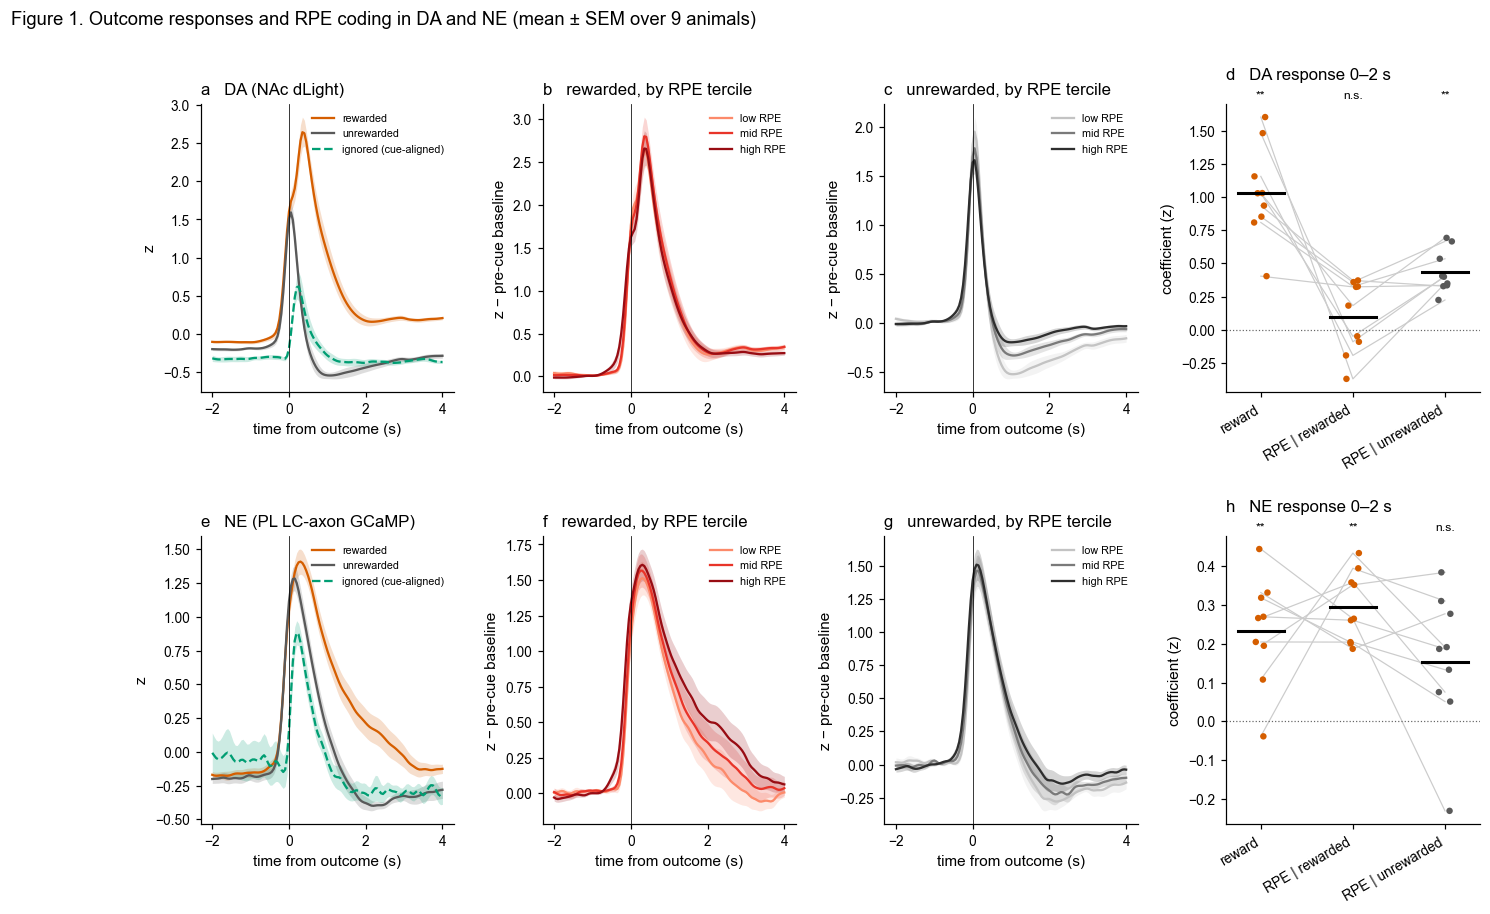

In [10]:
fig = plt.figure(figsize=(15, 8.5))
gs = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35)
seq = {"rew": plt.cm.Reds(np.linspace(0.4, 0.9, N_RPE_BINS)),
       "unrew": plt.cm.Greys(np.linspace(0.35, 0.85, N_RPE_BINS))}

for i, sig in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[i, 0])
    grand_trace(ax, peth[(sig, "rewarded")], LAGS, PALETTE["pos"], "rewarded")
    grand_trace(ax, peth[(sig, "unrewarded")], LAGS, "0.35", "unrewarded")
    grand_trace(ax, peth[(sig, "ignored (cue)")], LAGS, OKABE_ITO["bluish_green"],
                "ignored (cue-aligned)", ls="--")
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("time from outcome (s)")
    ax.set_ylabel("z")
    ax.set_title(f"{'ae'[i]}   {SIG_LABEL[sig]}", loc="left")
    ax.legend(fontsize=7)
    style_ax(ax)
    for j, cls in enumerate(("rew", "unrew")):
        ax = fig.add_subplot(gs[i, 1 + j])
        for k in range(N_RPE_BINS):
            key = (sig, f"{cls} RPE{k}")
            if key in peth:
                grand_trace(ax, peth[key], LAGS, seq[cls][k],
                            ["low", "mid", "high"][k] + " RPE")
        ax.axvline(0, color="k", lw=0.5)
        ax.set_xlabel("time from outcome (s)")
        ax.set_ylabel("z − pre-cue baseline")
        ax.set_title(f"{'bf'[i] if j == 0 else 'cg'[i]}   "
                     f"{'rewarded' if cls == 'rew' else 'unrewarded'}, by RPE tercile", loc="left")
        ax.legend(fontsize=7)
        style_ax(ax)
    ax = fig.add_subplot(gs[i, 3])
    g = rpe_animal.xs((sig, "full"), level=["sig", "window"])
    animal_strip(ax, g, ["reward", "rpe_rew", "rpe_unrew"],
                 ["reward", "RPE | rewarded", "RPE | unrewarded"],
                 [PALETTE["pos"], PALETTE["pos"], "0.35"], "coefficient (z)",
                 title=f"{'dh'[i]}   {sig.upper()} response 0–2 s")
fig.suptitle("Figure 1. Outcome responses and RPE coding in DA and NE "
             f"(mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_05_fig1_rpe_coding", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

Panels a and e are raw z. The pre-outcome level differs between conditions because DA's baseline
tracks value (section 4). Panels b, c, f and g subtract each trial's pre-cue baseline, as the
regression does, so their differences are the phasic modulation alone.

### When in the response does RPE scaling appear?

The response time is ≈0.2 s, so the go-cue response and the outcome response overlap in any
window after the outcome. The cue response is expected to scale with the value of the upcoming
choice (larger when Q_chosen is high) and the outcome response with RPE (larger when Q_chosen is
low). Within one outcome class RPE is Q_chosen with the sign flipped, so a single window sums the
two with opposite signs, and the 0–2 s coefficients in panels d and h can hide both.

Here the regression `z(t) ~ 1 + rewarded + RPE·rewarded + RPE·unrewarded + RT + trial position`
is fit at every time point around the outcome (one least-squares solve per session for all time
points), with the pre-cue baseline handled two ways: **subtracted** from z(t), or entered as a
**covariate**. The choice matters for DA because DA's baseline tracks value (section 4) and,
within an outcome, RPE is value with the sign flipped: subtracting a value-correlated baseline puts
an RPE-signed term into z(t) − baseline wherever the signal does not carry the baseline forward,
while entering it as a covariate lets the baseline absorb variance RPE shares with it. Neither is
neutral, so both are shown; a result that holds in both does not depend on the choice.
A positive RPE coefficient is RPE-like; a negative one means the response grows with the value of
the choice, which is what a value-scaled cue or choice response would produce. Shading is SEM
over animals; dots mark time points where the Wilcoxon over animals is p < 0.05.

In [11]:
TR_LAGS = np.arange(-0.5, 3.0 + 1e-9, 1 / FS)
BASELINE_MODES = ("subtracted", "covariate")
tr_coef = {}  # (mode, sig, term) -> per-animal (n_lags,) coefficient traces
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        g = resp[resp.session == p["session"]]
        if len(g) < 30:
            continue
        g = g.dropna(subset=RPE_NUISANCE + ["da_pre", "ne_pre"])
        r = g["rewarded"].to_numpy(float)
        rpe = g[RPE_COL].to_numpy(float)
        X0 = np.c_[np.ones(len(g)), r, rpe * r, rpe * (1 - r), g[RPE_NUISANCE].to_numpy(float)]
        for sig in ("da", "ne"):
            z = fc.zscore(p[sig])
            Y = fc.peri_event(z, p["t0"], FS, g["reward_outcome_time_in_session"], TR_LAGS)
            pre = g[f"{sig}_pre"].to_numpy()
            ok = np.isfinite(Y).all(1)
            for mode in BASELINE_MODES:
                X, YY = (X0, Y - pre[:, None]) if mode == "subtracted" else (np.c_[X0, pre], Y)
                beta, *_ = np.linalg.lstsq(X[ok], YY[ok], rcond=None)
                for k, term in enumerate(("intercept", "reward", "rpe_rew", "rpe_unrew")):
                    acc.setdefault((mode, sig, term), []).append(beta[k])
    for key, v in acc.items():
        tr_coef.setdefault(key, []).append(np.mean(v, 0))
tr_coef = {k: np.stack(v) for k, v in tr_coef.items()}

# Mean coefficient in an early and a late part of the response, per animal.
EARLY, LATE = (0.0, 0.5), (0.75, 2.0)
rows = []
for mode in BASELINE_MODES:
    for sig in ("da", "ne"):
        for term in ("rpe_rew", "rpe_unrew"):
            for name, (a, b) in (("early", EARLY), ("late", LATE)):
                v = tr_coef[(mode, sig, term)][:, (TR_LAGS >= a) & (TR_LAGS < b)].mean(1)
                m, pv, n = fc.wilcoxon_animals(v)
                rows.append(dict(baseline=mode, signal=sig, term=term, part=f"{name} {a}-{b} s",
                                 mean=m, p=pv, n_positive=f"{int((v > 0).sum())}/{n}"))
tr_summary = pd.DataFrame(rows).set_index(["signal", "term", "part", "baseline"]).sort_index()
tr_summary.round(3)

mean      p n_positive
signal term      part            baseline                           
da     rpe_rew   early 0.0-0.5 s covariate  -0.004  0.910        4/9
                                 subtracted  0.351  0.008        8/9
                 late 0.75-2.0 s covariate  -0.449  0.004        0/9
                                 subtracted -0.025  1.000        4/9
       rpe_unrew early 0.0-0.5 s covariate  -0.160  0.164        2/9
                                 subtracted  0.224  0.027        7/9
                 late 0.75-2.0 s covariate   0.074  0.164        7/9
                                 subtracted  0.524  0.004        9/9
ne     rpe_rew   early 0.0-0.5 s covariate   0.193  0.004        9/9
                                 subtracted  0.252  0.004        9/9
                 late 0.75-2.0 s covariate   0.273  0.004        9/9
                                 subtracted  0.327  0.004        9/9
       rpe_unrew early 0.0-0.5 s covariate   0.015  0.652        5/9
                                 subtracted  0.092  0.203        6/9
                 late 0.75-2.0 s covariate   0.117  0.129        6/9
                                 subtracted  0.191  0.039        8/9

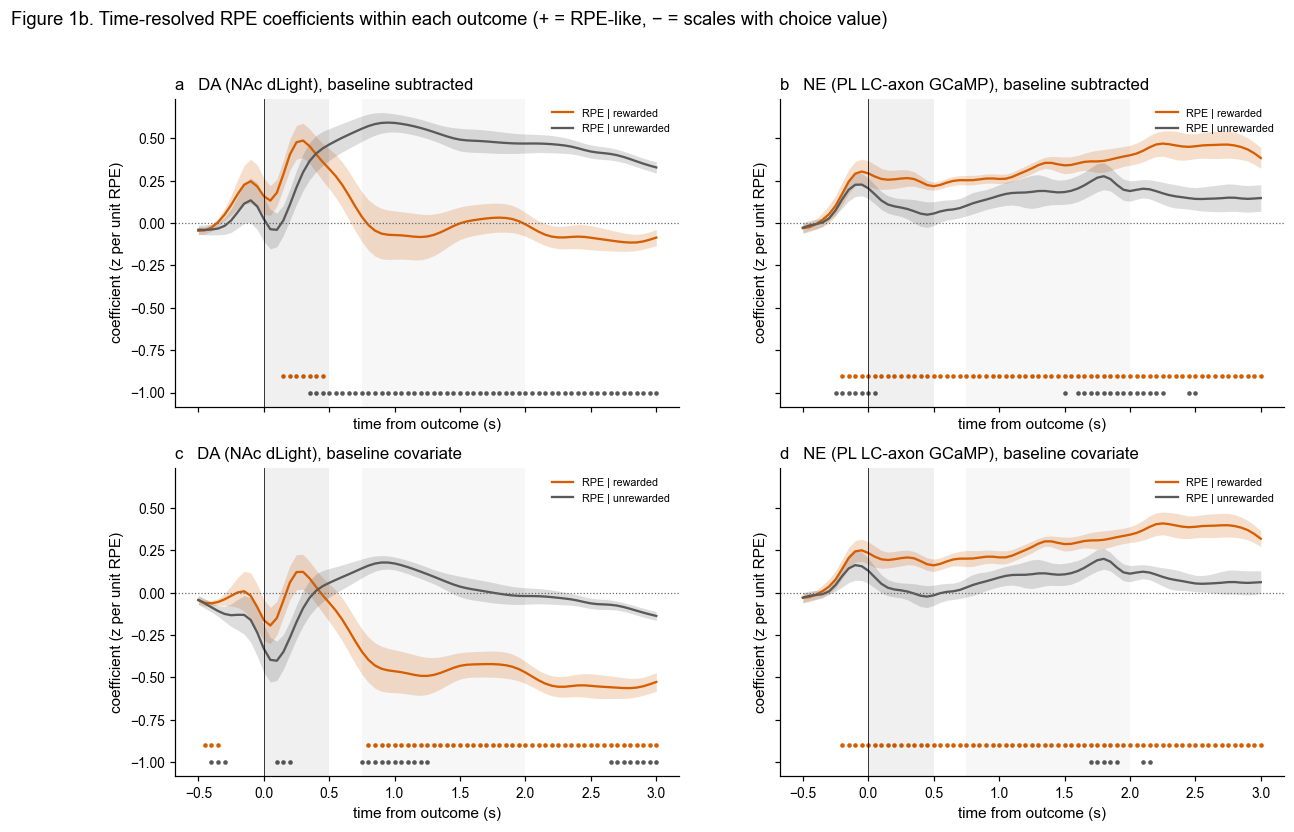

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True, sharex=True)
for (row, mode), (col_i, sig) in [(rm, cs) for rm in enumerate(BASELINE_MODES)
                                  for cs in enumerate(("da", "ne"))]:
    ax = axes[row, col_i]
    for term, col, lab in (("rpe_rew", PALETTE["pos"], "RPE | rewarded"),
                           ("rpe_unrew", "0.35", "RPE | unrewarded")):
        A = tr_coef[(mode, sig, term)]
        m_, se = A.mean(0), A.std(0) / np.sqrt(len(A))
        ax.plot(TR_LAGS, m_, color=col, label=lab)
        ax.fill_between(TR_LAGS, m_ - se, m_ + se, color=col, alpha=0.2, lw=0)
        p_t = np.array([fc.wilcoxon_animals(A[:, k])[1] for k in range(A.shape[1])])
        y_dot = -0.9 if term == "rpe_rew" else -1.0
        ax.scatter(TR_LAGS[p_t < 0.05], np.full((p_t < 0.05).sum(), y_dot), s=4, color=col)
    ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
    ax.axvline(0, color="k", lw=0.5)
    for (a, b), shade in ((EARLY, 0.06), (LATE, 0.03)):
        ax.axvspan(a, b, color="k", alpha=shade, lw=0)
    ax.set_xlabel("time from outcome (s)")
    ax.set_ylabel("coefficient (z per unit RPE)")
    ax.set_title(f"{'abcd'[2 * row + col_i]}   {SIG_LABEL[sig]}, baseline {mode}", loc="left")
    ax.legend(fontsize=7, loc="upper right")
    style_ax(ax)
fig.suptitle("Figure 1b. Time-resolved RPE coefficients within each outcome "
             "(+ = RPE-like, − = scales with choice value)", x=0.01, ha="left")
save_fig(fig, "fip_05_fig1b_rpe_timecourse", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### How alike are DA's and NE's outcome and RPE tuning?

The per-session coefficients of the 0–2 s regression above (`rpe_terms`: reward, RPE | rewarded,
RPE | unrewarded, with response time and trial position as nuisance terms) are compared between
DA and NE at three levels:

- **trial** — within a session, each signal's outcome + RPE prediction for every trial (its three
  coefficients times that trial's outcome and RPE) is correlated between DA and NE across trials.
  The predictions differ only through the coefficients, so this r measures how closely the two
  coefficient sets point the same way, weighted by how much each term varies across trials. The
  reward term varies most, so r approaches 1 whenever both signals are higher after rewards.
- **session** — across sessions, DA's coefficient against NE's, each centred on its animal's
  mean: within an animal, do sessions with a larger DA term also have a larger NE term?
- **animal** — across the animal means of each coefficient.

Session and animal levels use Spearman ρ; the trial level is Pearson r within session, averaged.

In [13]:
TERMS = ["reward", "rpe_rew", "rpe_unrew"]
TERM_LABEL = {"reward": "reward", "rpe_rew": "RPE | rewarded", "rpe_unrew": "RPE | unrewarded"}
coef = rpe_terms.pivot_table(index=["subject", "session", "window"], columns="sig", values=TERMS)

# Trial level: correlation across trials of the two signals' outcome + RPE predictions.
rows = []
for (subj, sess), g in resp.groupby(["subject", "session"]):
    g = g.dropna(subset=RPE_NUISANCE)
    r = g["rewarded"].to_numpy(float)
    rpe = g[RPE_COL].to_numpy(float)
    X = np.c_[r, rpe * r, rpe * (1 - r)]
    d = dict(subject=subj, session=sess)
    for w in RESP_WINS:
        pred = {sig: X @ coef.loc[(subj, sess, w), [(t, sig) for t in TERMS]].to_numpy(float)
                for sig in ("da", "ne")}
        d[w] = sess_corr(pd.DataFrame(pred), "da", "ne")
    rows.append(d)
tuning_trial_animal = fc.animal_means(pd.DataFrame(rows), list(RESP_WINS), by_session=False)

# Session level (centred within animal) and animal level: correlation of DA's and NE's coefficients.
coef_centred = coef - coef.groupby(level=["subject", "window"]).transform("mean")
coef_animal = coef.groupby(level=["subject", "window"]).mean()
rows = []
for w in RESP_WINS:
    m, p, n = fc.wilcoxon_animals(tuning_trial_animal[w])
    rows.append(dict(window=w, level="trial", term="outcome + RPE fit", r=m, p=p, n=n))
    for level, tbl in (("session (within animal)", coef_centred), ("animal", coef_animal)):
        t = tbl.xs(w, level="window")
        for term in TERMS:
            rr, pp = stats.spearmanr(t[(term, "da")], t[(term, "ne")])
            rows.append(dict(window=w, level=level, term=term, r=rr, p=pp, n=len(t)))
tuning_summary = pd.DataFrame(rows).set_index(["window", "level", "term"])
tuning_summary.round(3)

r      p   n
window level                   term                               
early  trial                   outcome + RPE fit  0.581  0.004   9
       session (within animal) reward             0.261  0.011  95
                               rpe_rew            0.385  0.000  95
                               rpe_unrew          0.155  0.134  95
       animal                  reward             0.550  0.125   9
                               rpe_rew            0.717  0.030   9
                               rpe_unrew          0.483  0.187   9
late   trial                   outcome + RPE fit  0.881  0.004   9
       session (within animal) reward             0.208  0.044  95
                               rpe_rew            0.109  0.295  95
                               rpe_unrew          0.365  0.000  95
       animal                  reward            -0.033  0.932   9
                               rpe_rew           -0.517  0.154   9
                               rpe_unrew          0.383  0.308   9
full   trial                   outcome + RPE fit  0.894  0.004   9
       session (within animal) reward             0.226  0.027  95
                               rpe_rew            0.232  0.024  95
                               rpe_unrew          0.314  0.002  95
       animal                  reward             0.267  0.488   9
                               rpe_rew           -0.283  0.460   9
                               rpe_unrew          0.383  0.308   9

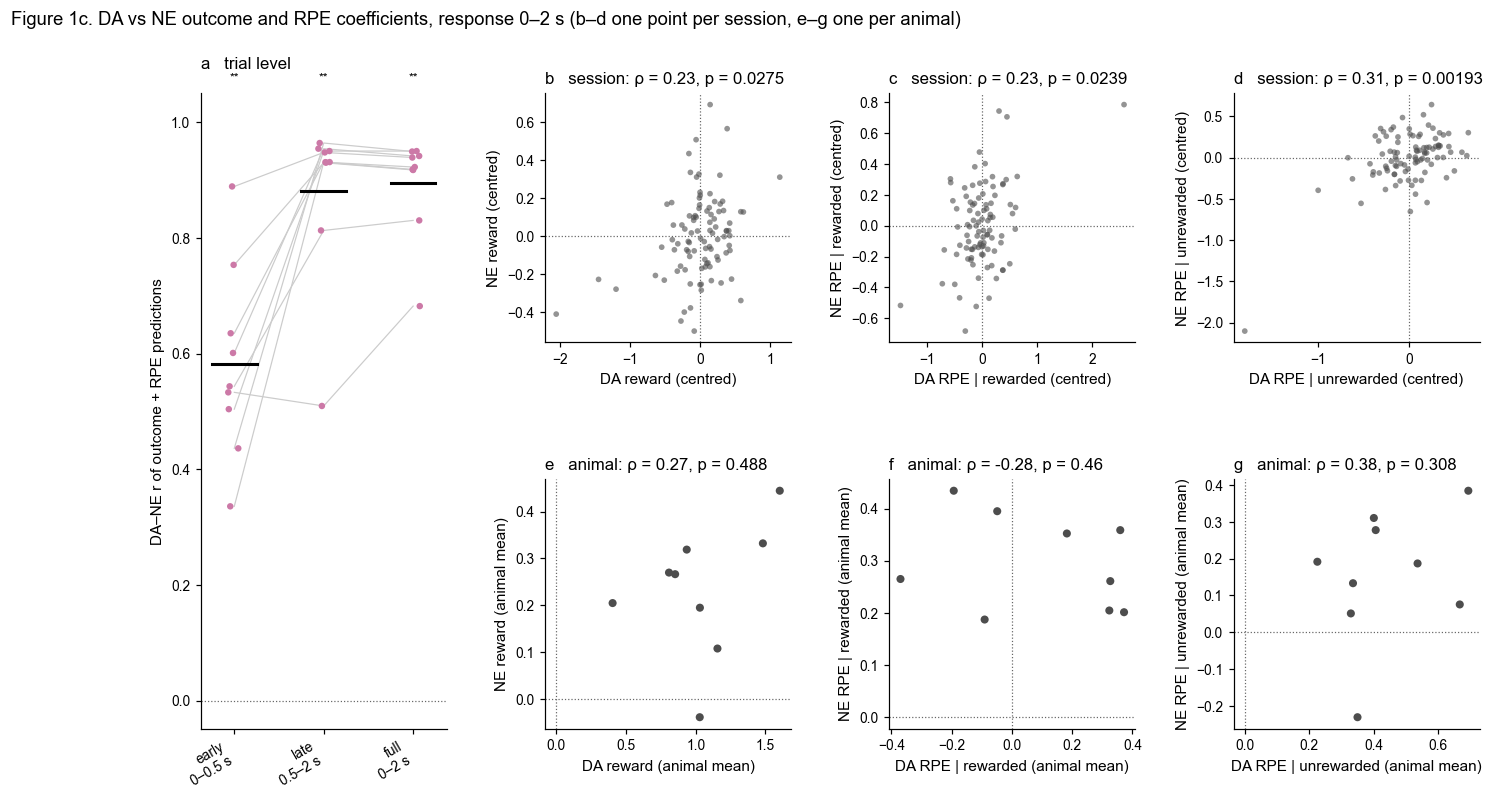

In [14]:
fig = plt.figure(figsize=(15, 7.5))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 1], hspace=0.55, wspace=0.4)

ax = fig.add_subplot(gs[:, 0])
animal_strip(ax, tuning_trial_animal, list(RESP_WINS), ["early\n0–0.5 s", "late\n0.5–2 s", "full\n0–2 s"],
             [PALETTE["accent"]] * 3, "DA–NE r of outcome + RPE predictions",
             title="a   trial level")
ax.set_ylim(top=1.05)

for row_i, (level, tbl, xlab) in enumerate((("session (within animal)", coef_centred, "centred"),
                                            ("animal", coef_animal, "animal mean"))):
    t = tbl.xs("full", level="window")
    for j, term in enumerate(TERMS):
        ax = fig.add_subplot(gs[row_i, 1 + j])
        x, y = t[(term, "da")], t[(term, "ne")]
        ax.scatter(x, y, s=14 if row_i == 0 else 28, color="0.3", edgecolor="none",
                   alpha=0.6 if row_i == 0 else 1)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.axvline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        rr, pp = tuning_summary.loc[("full", level, term), ["r", "p"]]
        ax.set_xlabel(f"DA {TERM_LABEL[term]} ({xlab})")
        ax.set_ylabel(f"NE {TERM_LABEL[term]} ({xlab})")
        letter = "bcdefg"[3 * row_i + j]
        ax.set_title(f"{letter}   {level.split()[0]}: ρ = {rr:.2f}, p = {pp:.3g}", loc="left")
        style_ax(ax)
fig.suptitle("Figure 1c. DA vs NE outcome and RPE coefficients, response 0–2 s "
             "(b–d one point per session, e–g one per animal)", x=0.01, ha="left")
save_fig(fig, "fip_05_fig1c_tuning_similarity", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. Do outcome responses covary trial by trial?

For each session, DA and NE outcome responses (baseline-subtracted, per window) are correlated
across responded trials in three ways:

- **total** — all trials;
- **within rewarded / within unrewarded** — trials split by outcome, which removes the outcome
  main effect (two signals that are both higher after rewards correlate for that reason alone);
- **residual** — each response is regressed on reward and on RPE within each outcome, per session
  (`fc.residualize`), and the residuals are correlated. Within an outcome RPE is 1 − Q_chosen or
  −Q_chosen, so chosen value is removed too. The residual r asks whether, on a given trial, DA's
  departure from what outcome and RPE predict goes with NE's.

Section 2b adds response time, trial position and pre-cue baseline to this model one at a time.

In [15]:
RPE_COVS = ["rewarded", "rpe_x_rew", "rpe_x_unrew"]  # outcome + RPE within each outcome

for w in RESP_WINS:
    for sig in ("da", "ne"):
        resp[f"{sig}_{w}_resid"] = fc.residualize(resp, f"{sig}_{w}", RPE_COVS)

rows = []
for (subj, sess), g in resp.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for w in RESP_WINS:
        d[f"total_{w}"] = sess_corr(g, f"da_{w}", f"ne_{w}")
        d[f"rewarded_{w}"] = sess_corr(g[g.rewarded], f"da_{w}", f"ne_{w}")
        d[f"unrewarded_{w}"] = sess_corr(g[~g.rewarded], f"da_{w}", f"ne_{w}")
        d[f"residual_{w}"] = sess_corr(g, f"da_{w}_resid", f"ne_{w}_resid")
    rows.append(d)
resp_corr = pd.DataFrame(rows)
resp_corr_animal = fc.animal_means(resp_corr, [c for c in resp_corr if "_" in c and c not in ("subject", "session")], by_session=False)

rows = []
for c in resp_corr_animal:
    m, p, n = fc.wilcoxon_animals(resp_corr_animal[c])
    kind, w = c.rsplit("_", 1)
    rows.append(dict(window=w, correlation=kind, mean_r=m, p=p, n_positive=int((resp_corr_animal[c] > 0).sum()), n=n))
pd.DataFrame(rows).set_index(["window", "correlation"]).round(3)

mean_r      p  n_positive  n
window correlation                              
early  total         0.176  0.004           9  9
       rewarded      0.162  0.004           9  9
       unrewarded    0.116  0.020           8  9
       residual      0.143  0.004           9  9
late   total         0.323  0.008           8  9
       rewarded      0.146  0.020           8  9
       unrewarded    0.121  0.074           7  9
       residual      0.125  0.027           8  9
full   total         0.313  0.004           9  9
       rewarded      0.144  0.020           8  9
       unrewarded    0.124  0.055           7  9
       residual      0.131  0.027           8  9

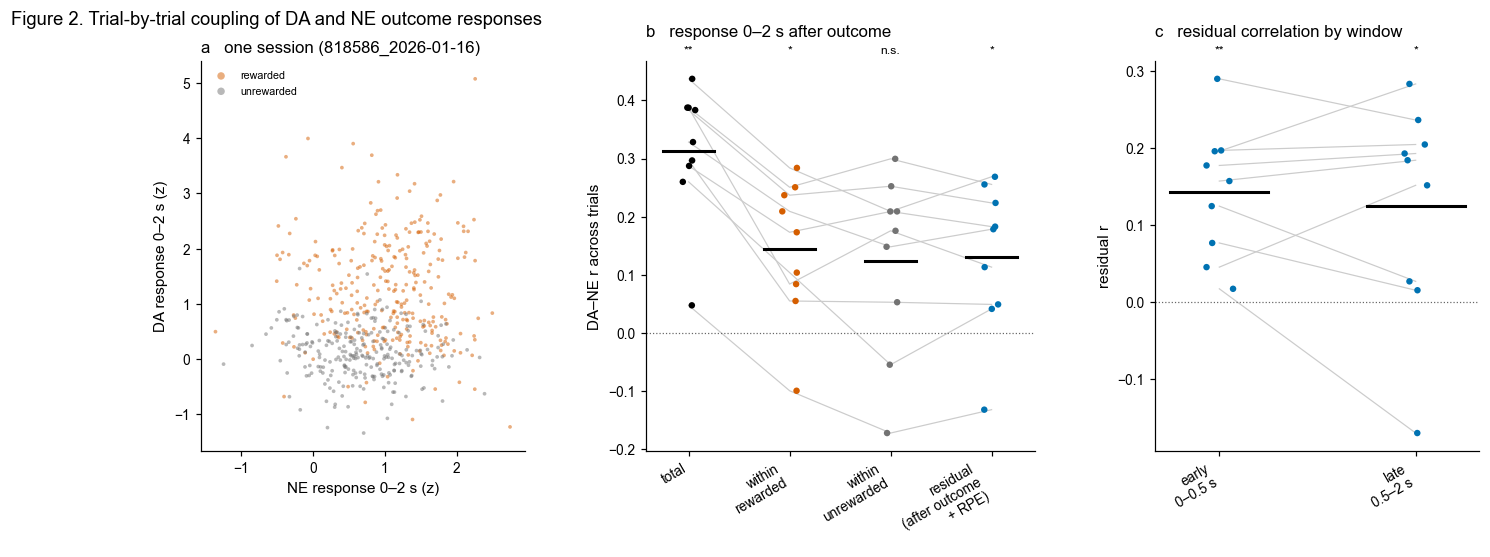

In [16]:
fig = plt.figure(figsize=(15, 4.6))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1.2, 1], wspace=0.35)

ax = fig.add_subplot(gs[0])
g = resp[resp.session == ex["session"]]
for rew, col, lab in ((True, PALETTE["pos"], "rewarded"), (False, "0.45", "unrewarded")):
    h = g[g.rewarded == rew]
    ax.scatter(h["ne_full"], h["da_full"], s=6, color=col, alpha=0.5, label=lab, edgecolor="none")
ax.set_xlabel("NE response 0–2 s (z)")
ax.set_ylabel("DA response 0–2 s (z)")
ax.set_title(f"a   one session ({ex['session']})", loc="left")
ax.legend(fontsize=7, markerscale=2)
style_ax(ax)

ax = fig.add_subplot(gs[1])
kinds = ["total", "rewarded", "unrewarded", "residual"]
animal_strip(ax, resp_corr_animal, [f"{k}_full" for k in kinds],
             ["total", "within\nrewarded", "within\nunrewarded", "residual\n(after outcome\n+ RPE)"],
             ["k", PALETTE["pos"], "0.45", OKABE_ITO["blue"]],
             "DA–NE r across trials", title="b   response 0–2 s after outcome")

ax = fig.add_subplot(gs[2])
animal_strip(ax, resp_corr_animal, [f"residual_{w}" for w in ("early", "late")],
             ["early\n0–0.5 s", "late\n0.5–2 s"], [OKABE_ITO["blue"]] * 2,
             "residual r", title="c   residual correlation by window")
fig.suptitle("Figure 2. Trial-by-trial coupling of DA and NE outcome responses", x=0.01, ha="left")
save_fig(fig, "fip_05_fig2_trial_coupling", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### 2b. Controls on the residual correlation

Each control adds one set of covariates to the outcome + RPE model, on its own, and recomputes the
residual correlation. All four versions use the same trials (those with every covariate present).

- **+ response time.** Windows are aligned to the outcome, so a slow trial's window holds less of
  the cue response than a fast trial's. Timing that moves both signals together gives them a
  shared residual. Response time may also index a state both signals follow, such as engagement;
  this control removes both.
- **+ trial position.** Drift across the session in both channels (bleaching, satiety) is a shared
  slow component.
- **+ both pre-cue baselines.** Each response has its own baseline subtracted, so if the DA and NE
  baselines covary (section 4), that covariation carries into the responses. `da_pre` and `ne_pre`
  both enter both models.

In [17]:
CONTROLS = {
    "outcome + RPE": [],
    "+ response time": ["response_time"],
    "+ trial position": ["trial_frac"],
    "+ both baselines": ["da_pre", "ne_pre"],
}
ctrl = resp.dropna(subset=sorted({c for v in CONTROLS.values() for c in v})).copy()
for name, extra_covs in CONTROLS.items():
    for w in RESP_WINS:
        for sig in ("da", "ne"):
            ctrl[f"{sig}_{w}_{name}"] = fc.residualize(ctrl, f"{sig}_{w}", RPE_COVS + extra_covs)

rows = []
for (subj, sess), g in ctrl.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for name in CONTROLS:
        for w in RESP_WINS:
            d[f"{name}|{w}"] = sess_corr(g, f"da_{w}_{name}", f"ne_{w}_{name}")
    rows.append(d)
ctrl_corr = pd.DataFrame(rows)
ctrl_corr_animal = fc.animal_means(ctrl_corr, [c for c in ctrl_corr if "|" in c], by_session=False)

rows = []
for w in RESP_WINS:
    base = ctrl_corr_animal[f"outcome + RPE|{w}"]
    for name in CONTROLS:
        v = ctrl_corr_animal[f"{name}|{w}"]
        m, p, n = fc.wilcoxon_animals(v)
        dm, dp = ((0.0, np.nan) if name == "outcome + RPE"
                  else fc.wilcoxon_animals(v - base)[:2])
        rows.append(dict(window=w, model=name, mean_r=m, p=p, n_positive=int((v > 0).sum()),
                         change_vs_outcome_rpe=dm, p_change=dp))
ctrl_summary = pd.DataFrame(rows).set_index(["window", "model"])
ctrl_summary.round(3)

mean_r      p  n_positive  change_vs_outcome_rpe  p_change
window model                                                                       
early  outcome + RPE      0.143  0.004           9                  0.000       NaN
       + response time    0.126  0.008           8                 -0.017     0.074
       + trial position   0.154  0.004           9                  0.011     0.496
       + both baselines   0.141  0.004           9                 -0.001     1.000
late   outcome + RPE      0.125  0.027           8                  0.000       NaN
       + response time    0.127  0.027           8                  0.002     0.652
       + trial position   0.130  0.027           8                  0.004     0.426
       + both baselines   0.113  0.074           7                 -0.013     0.203
full   outcome + RPE      0.131  0.027           8                  0.000       NaN
       + response time    0.135  0.027           8                  0.004     0.301
       + trial position   0.139  0.027           8                  0.008     0.301
       + both baselines   0.118  0.039           8                 -0.013     0.301

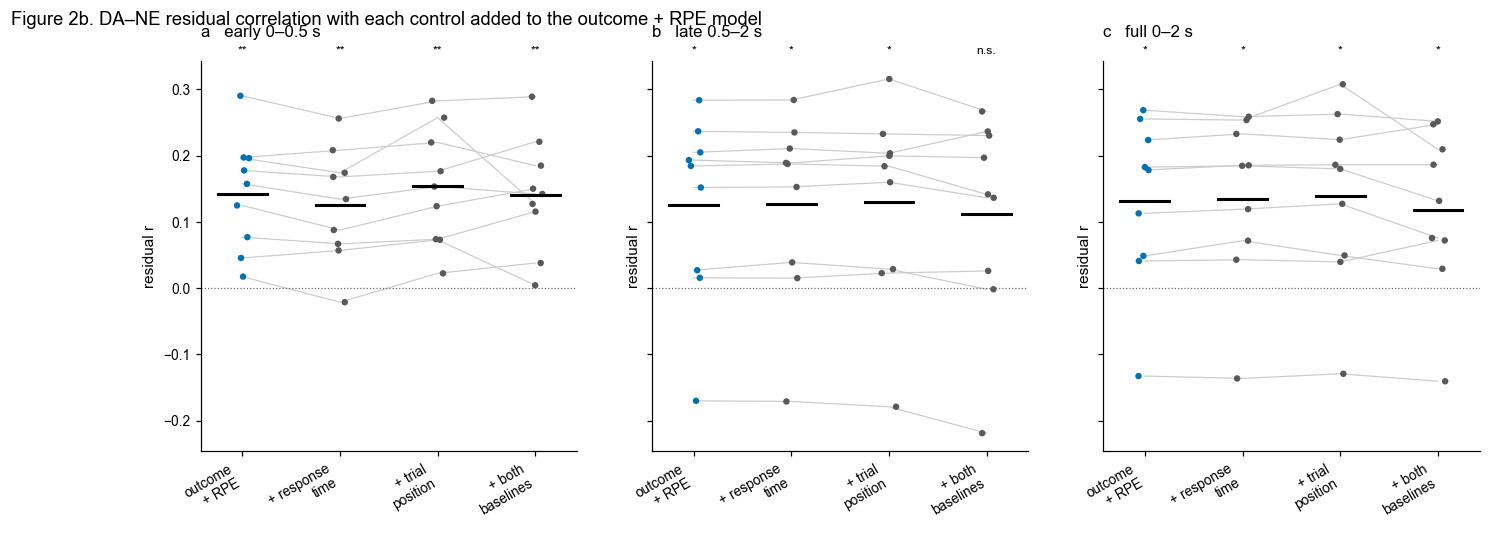

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
names = list(CONTROLS)
for ax, (w, (a, b)) in zip(axes, RESP_WINS.items()):
    animal_strip(ax, ctrl_corr_animal, [f"{n}|{w}" for n in names],
                 ["outcome\n+ RPE", "+ response\ntime", "+ trial\nposition", "+ both\nbaselines"],
                 [OKABE_ITO["blue"]] + ["0.35"] * 3, "residual r",
                 title=f"{'abc'[list(RESP_WINS).index(w)]}   {w} {a:g}–{b:g} s")
fig.suptitle("Figure 2b. DA–NE residual correlation with each control added to the outcome + RPE "
             "model", x=0.01, ha="left")
save_fig(fig, "fip_05_fig2b_residual_controls", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. Do phasic events line up in timing and magnitude?

Three views, from the most task-constrained to the least:

- **a–c: the task-locked response.** Peak latency after the go cue for each signal, and whether a
  trial with a late DA peak also has a late NE peak. The trial-by-trial latency correlation is
  shown raw and with response time partialled out, since both peaks could simply follow the lick.
- **d–e: every large transient.** Each large DA transient (prominence ≥ `LARGE_PROM` z) is paired
  with the nearest NE transient (prominence ≥ `PARTNER_PROM`); the lag distribution is compared
  with circularly shifted NE trains. For matched pairs, the DA and NE prominences are correlated
  within each task context, so that the reward-vs-omission difference in both signals cannot by
  itself produce the correlation.
- **f: the continuous residual.** Cross-correlation of the two signals after event-locked responses
  are regressed out (section 4 describes the model), which measures timing of the covariation the
  task does not explain.

In [19]:
lat = resp.dropna(subset=["da_lat", "ne_lat"]).copy()
for sig in ("da", "ne"):
    lat[f"{sig}_lat_resid"] = fc.residualize(lat, f"{sig}_lat", ["response_time"])
rows = []
for (subj, sess), g in lat.groupby(["subject", "session"]):
    rows.append(dict(subject=subj, session=sess,
                     da_lat=g.da_lat.median(), ne_lat=g.ne_lat.median(),
                     r_lat=stats.spearmanr(g.da_lat, g.ne_lat)[0],
                     r_lat_partial=stats.spearmanr(g.da_lat_resid, g.ne_lat_resid)[0],
                     r_da_rt=stats.spearmanr(g.da_lat, g.response_time)[0],
                     r_ne_rt=stats.spearmanr(g.ne_lat, g.response_time)[0]))
lat_sess = pd.DataFrame(rows)
lat_animal = fc.animal_means(lat_sess, ["da_lat", "ne_lat", "r_lat", "r_lat_partial",
                                        "r_da_rt", "r_ne_rt"], by_session=False)
lat_animal["ne_minus_da"] = lat_animal["ne_lat"] - lat_animal["da_lat"]
for c in lat_animal:
    m, p, n = fc.wilcoxon_animals(lat_animal[c])
    print(f"{c:15s} mean {m:+.3f}  p = {p:.4f}  (n = {n})")

da_lat          mean +0.274  p = 0.0039  (n = 9)
ne_lat          mean +0.472  p = 0.0039  (n = 9)
r_lat           mean +0.211  p = 0.0039  (n = 9)
r_lat_partial   mean +0.212  p = 0.0039  (n = 9)
r_da_rt         mean +0.053  p = 0.0039  (n = 9)
r_ne_rt         mean +0.085  p = 0.0039  (n = 9)
ne_minus_da     mean +0.198  p = 0.0039  (n = 9)


In [20]:
# Cue-aligned rewarded-trial traces, normalized to each animal's peak, for panel a.
cue_peth = {"da": [], "ne": []}
for subj in SUBJECTS:
    acc = {"da": [], "ne": []}
    for p in (p for p in pairs if p["subject"] == subj):
        tr = p["trials"]
        m = (tr["animal_response"] < 2) & tr["earned_reward"].astype(bool)
        for sig in ("da", "ne"):
            seg = fc.peri_event(fc.zscore(p[sig]), p["t0"], FS,
                                tr.loc[m, "goCue_start_time_in_session"], LAGS)
            acc[sig].append(np.nanmean(seg, 0))
    for sig in ("da", "ne"):
        tr_mean = np.mean(acc[sig], 0)
        base = tr_mean[(LAGS >= -1) & (LAGS < 0)].mean()
        cue_peth[sig].append((tr_mean - base) / (tr_mean - base).max())

# Transient detection and pairing, per session.
trans_rows, pair_rows = [], []
for p in pairs:
    z = {s: fc.zscore(p[s]) for s in ("da", "ne")}
    dur = len(z["da"]) / FS
    det = {s: fc.detect_transients(z[s], FS, prominence=PARTNER_PROM) for s in ("da", "ne")}
    for s in ("da", "ne"):
        d = det[s]
        d["t"] = p["t0"] + d["i"] / FS
        d["context"] = fc.label_context(d["t"].to_numpy(), p)
        d["sig"] = s
        d["subject"], d["session"], d["dur"] = p["subject"], p["session"], dur
        trans_rows.append(d)
    # Pair each large transient with the nearest partner-level transient in the other signal.
    for s, o in (("da", "ne"), ("ne", "da")):
        big = det[s][det[s]["prominence"] >= LARGE_PROM]
        idx, lag = fc.nearest_partner(big["t"].to_numpy(), det[o]["t"].to_numpy())
        null = fc.shift_coincidence_null(big["t"].to_numpy() - p["t0"],
                                         det[o]["t"].to_numpy() - p["t0"], dur, MATCH_WIN_S,
                                         n_null=100, rng=rng)
        pr = pd.DataFrame(dict(subject=p["subject"], session=p["session"], sig=s, t=big["t"].values,
                               prominence=big["prominence"].values, context=big["context"].values,
                               lag=lag, partner_prom=det[o]["prominence"].to_numpy()[idx]
                               if len(det[o]) else np.nan,
                               null_frac=np.nanmean(null), dur=dur))
        pair_rows.append(pr)
transients = pd.concat(trans_rows, ignore_index=True)
paired = pd.concat(pair_rows, ignore_index=True)
paired["matched"] = paired["lag"].abs() <= MATCH_WIN_S
print(paired.groupby("sig")[["matched"]].mean().round(3))

     matched
sig         
da     0.833
ne     0.436


In [21]:
# Lag histograms (NE peak − DA peak), per animal, for large DA transients; null from a circular
# shift of the NE train, drawn once per session.
LAG_BINS = np.arange(-1.55, 1.55 + 1e-9, 0.1)  # 0.1-s bins centred on the 20-Hz sample grid
lag_hist, lag_null = [], []
for subj in SUBJECTS:
    h_obs, h_null = [], []
    for p in (p for p in pairs if p["subject"] == subj):
        g = paired[(paired.session == p["session"]) & (paired.sig == "da")]
        h_obs.append(np.histogram(g["lag"], LAG_BINS)[0] / max(len(g), 1))
        ne_t = transients[(transients.session == p["session"]) & (transients.sig == "ne")]["t"].to_numpy()
        dur = len(p["da"]) / FS
        shifted = np.sort((ne_t - p["t0"] + rng.uniform(30, dur - 30)) % dur) + p["t0"]
        _, l0 = fc.nearest_partner(g["t"].to_numpy(), shifted)
        h_null.append(np.histogram(l0, LAG_BINS)[0] / max(len(g), 1))
    lag_hist.append(np.mean(h_obs, 0))
    lag_null.append(np.mean(h_null, 0))
lag_hist, lag_null = np.array(lag_hist), np.array(lag_null)
centers = LAG_BINS[:-1] + 0.05
excess = lag_hist - lag_null
# Centre of mass of the positive excess within the match window: where the above-chance pairs sit.
in_win = np.abs(centers) <= MATCH_WIN_S
pos = np.clip(excess[:, in_win], 0, None)
peak_lag_animal = pd.Series((pos * centers[in_win]).sum(1) / pos.sum(1), index=SUBJECTS)
m, p, n = fc.wilcoxon_animals(peak_lag_animal)
print(f"centre of the excess coincidences (NE − DA): per-animal mean {m:+.3f} s, Wilcoxon p = {p:.4f}")
print("excess matched fraction within the window (observed − shifted):",
      pd.Series(excess[:, in_win].sum(1), index=SUBJECTS).round(3).to_dict())

# Amplitude coupling of matched pairs, within context.
CONTEXTS = ["rewarded", "unrewarded", "cue, no response", "licking", "quiet"]
mp = paired[(paired.sig == "da") & paired.matched]
amp_rows = []
for (subj, ctx), g in mp.groupby(["subject", "context"]):
    if len(g) >= 20:
        amp_rows.append(dict(subject=subj, context=ctx, n=len(g),
                             rho=stats.spearmanr(g["prominence"], g["partner_prom"])[0]))
amp = pd.DataFrame(amp_rows).pivot(index="subject", columns="context", values="rho")
amp = amp[[c for c in CONTEXTS if c in amp]]
for c in amp:
    m, p, n = fc.wilcoxon_animals(amp[c])
    print(f"amplitude rho, {c:17s}: mean {m:+.3f}, p = {p:.4f}, n = {n}")

centre of the excess coincidences (NE − DA): per-animal mean +0.084 s, Wilcoxon p = 0.0039
excess matched fraction within the window (observed − shifted): {'800886': 0.172, '808054': 0.24, '809487': 0.149, '809491': 0.181, '815334': 0.154, '816212': 0.066, '816214': 0.316, '818585': 0.07, '818586': 0.204}
amplitude rho, rewarded         : mean +0.106, p = 0.0039, n = 9
amplitude rho, unrewarded       : mean +0.058, p = 0.0977, n = 9
amplitude rho, cue, no response : mean -0.004, p = 1.0000, n = 8
amplitude rho, licking          : mean +0.065, p = 0.0977, n = 9
amplitude rho, quiet            : mean +0.130, p = 0.0039, n = 9


In [22]:
# Residual cross-correlation (needs section 5's task model; computed here and reused there).
residuals = {}
xc_rows = []
for p in pairs:
    r = fc.task_residuals(p, KERNEL_S)
    residuals[p["session"]] = r
    xl, xc = fc.residual_xcorr(r["da_res"], r["ne_res"], FS, maxlag_s=3.0)
    xl, xc_raw = fc.residual_xcorr(r["da"], r["ne"], FS, maxlag_s=3.0)
    xc_rows.append(dict(subject=p["subject"], session=p["session"], xc_res=xc, xc_raw=xc_raw,
                        r2_da=r["da_r2"], r2_ne=r["ne_r2"]))
xc_df = pd.DataFrame(xc_rows)
xc_res_animal = np.stack(xc_df.groupby("subject")["xc_res"].apply(lambda s: np.mean(np.stack(s), 0)))
xc_raw_animal = np.stack(xc_df.groupby("subject")["xc_raw"].apply(lambda s: np.mean(np.stack(s), 0)))
res_peak_lag = pd.Series(xl[np.argmax(np.abs(xc_res_animal), 1)], index=SUBJECTS)
raw_peak_lag = pd.Series(xl[np.argmax(xc_raw_animal, 1)], index=SUBJECTS)
print("raw xcorr peak lag per animal (s, + = NE later):", raw_peak_lag.round(2).to_dict())
print("residual xcorr peak lag per animal:", res_peak_lag.round(2).to_dict())
print("residual xcorr peak r per animal:",
      pd.Series(xc_res_animal[np.arange(N_ANIMALS), np.argmax(np.abs(xc_res_animal), 1)],
                index=SUBJECTS).round(3).to_dict())

raw xcorr peak lag per animal (s, + = NE later): {'800886': 0.0, '808054': 0.0, '809487': 0.0, '809491': 0.05, '815334': 0.05, '816212': 0.15, '816214': 0.15, '818585': 0.25, '818586': 0.1}
residual xcorr peak lag per animal: {'800886': -0.45, '808054': -0.5, '809487': -0.5, '809491': 0.05, '815334': 0.0, '816212': -0.1, '816214': 0.2, '818585': -0.1, '818586': -0.25}
residual xcorr peak r per animal: {'800886': 0.057, '808054': 0.099, '809487': 0.069, '809491': 0.167, '815334': 0.113, '816212': -0.132, '816214': 0.046, '818585': -0.066, '818586': -0.061}


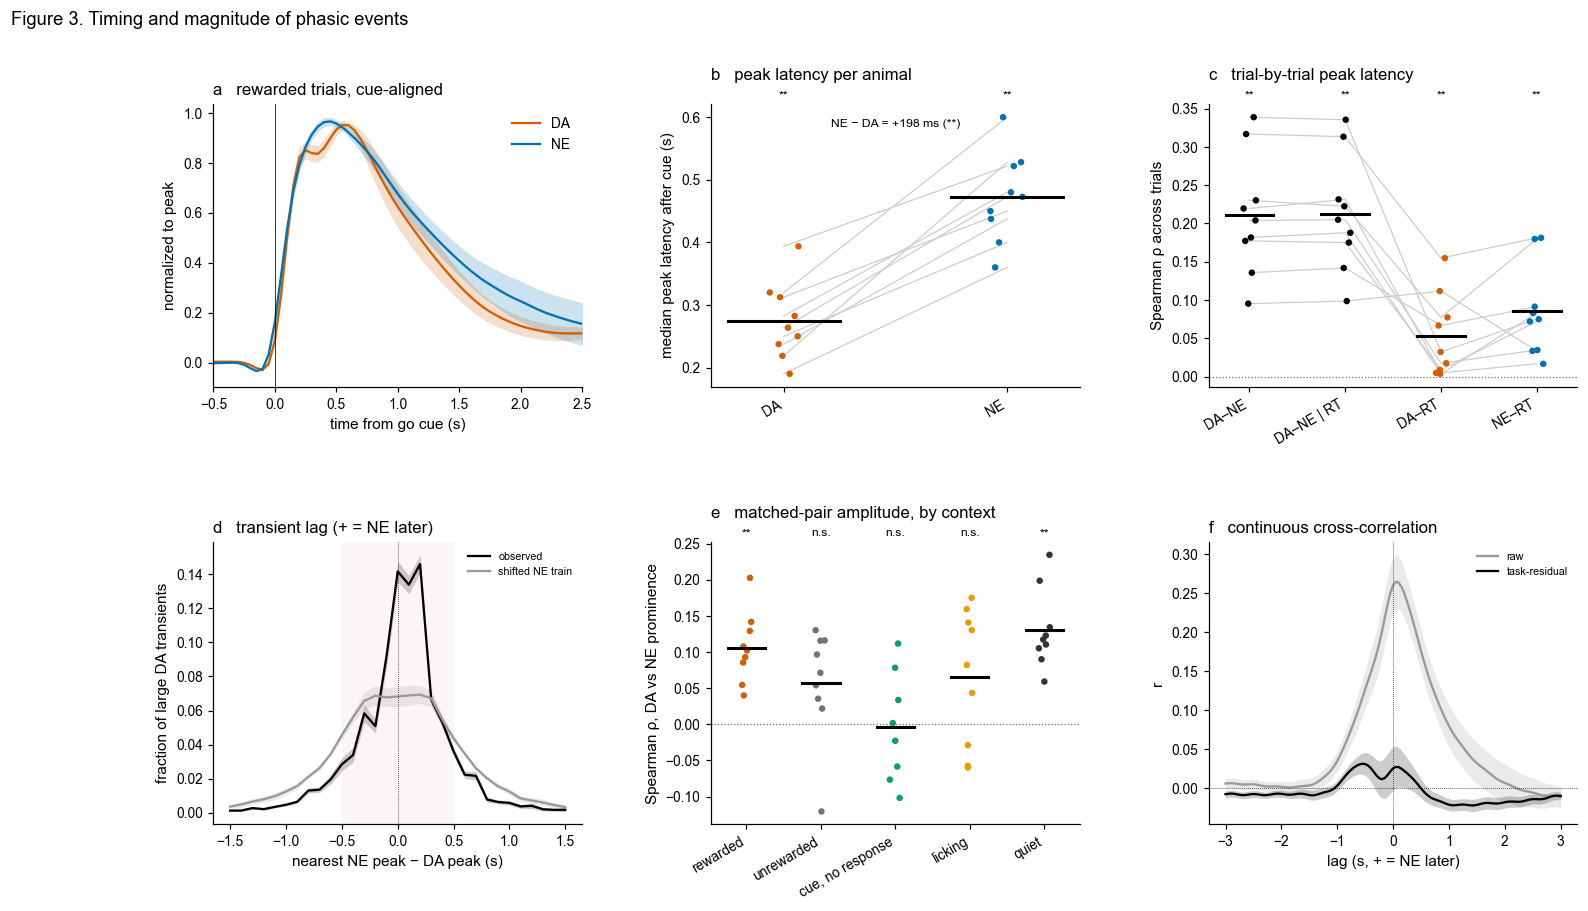

In [23]:
fig = plt.figure(figsize=(16, 8.5))
gs = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
for sig in ("da", "ne"):
    grand_trace(ax, cue_peth[sig], LAGS, SIG_COLOR[sig], sig.upper())
ax.axvline(0, color="k", lw=0.5)
ax.set_xlim(-0.5, 2.5)
ax.set_xlabel("time from go cue (s)")
ax.set_ylabel("normalized to peak")
ax.set_title("a   rewarded trials, cue-aligned", loc="left")
ax.legend()
style_ax(ax)

ax = fig.add_subplot(gs[0, 1])
animal_strip(ax, lat_animal, ["da_lat", "ne_lat"], ["DA", "NE"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "median peak latency after cue (s)",
             title="b   peak latency per animal", zero=False)
m, p, n = fc.wilcoxon_animals(lat_animal["ne_minus_da"])
ax.text(0.5, 0.92, f"NE − DA = {m * 1000:+.0f} ms ({stars(p)})", transform=ax.transAxes,
        ha="center", fontsize=8)

ax = fig.add_subplot(gs[0, 2])
animal_strip(ax, lat_animal, ["r_lat", "r_lat_partial", "r_da_rt", "r_ne_rt"],
             ["DA–NE", "DA–NE | RT", "DA–RT", "NE–RT"],
             ["k", "k", SIG_COLOR["da"], SIG_COLOR["ne"]], "Spearman ρ across trials",
             title="c   trial-by-trial peak latency")

ax = fig.add_subplot(gs[1, 0])
for arr, col, lab in ((lag_hist, "k", "observed"), (lag_null, "0.6", "shifted NE train")):
    m_ = arr.mean(0)
    se = arr.std(0) / np.sqrt(len(arr))
    ax.plot(centers, m_, color=col, label=lab)
    ax.fill_between(centers, m_ - se, m_ + se, color=col, alpha=0.2, lw=0)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axvspan(-MATCH_WIN_S, MATCH_WIN_S, color=PALETTE["accent"], alpha=0.07, lw=0)
ax.set_xlabel("nearest NE peak − DA peak (s)")
ax.set_ylabel("fraction of large DA transients")
ax.set_title("d   transient lag (+ = NE later)", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[1, 1])
animal_strip(ax, amp, list(amp.columns), list(amp.columns),
             [PALETTE["pos"], "0.45", OKABE_ITO["bluish_green"], OKABE_ITO["orange"], "0.2"][:len(amp.columns)],
             "Spearman ρ, DA vs NE prominence", title="e   matched-pair amplitude, by context",
             connect=False)

ax = fig.add_subplot(gs[1, 2])
for arr, col, lab in ((xc_raw_animal, "0.6", "raw"), (xc_res_animal, "k", "task-residual")):
    m_ = arr.mean(0)
    se = arr.std(0) / np.sqrt(len(arr))
    ax.plot(xl, m_, color=col, label=lab)
    ax.fill_between(xl, m_ - se, m_ + se, color=col, alpha=0.2, lw=0)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title("f   continuous cross-correlation", loc="left")
ax.legend(fontsize=7)
style_ax(ax)
fig.suptitle("Figure 3. Timing and magnitude of phasic events", x=0.01, ha="left")
save_fig(fig, "fip_05_fig3_phasic_timing", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 4. Do tonic levels covary, and on which timescales?

Three measurements:

- **Value in the baseline.** fip_01 found the pre-trial DA level tracks reward history. Whether NE's
  baseline does the same decides whether the two could share a tonic value signal at all.
  Pre-cue baseline (−1 to 0 s before the go cue) against the model's total value `Q_sum`.
- **Baseline coupling.** DA and NE pre-cue baselines correlated across trials within session:
  raw, after regressing out value (`Q_sum`) and trial position, and after a 20-trial running mean
  (slow drift only).
- **Timescale-resolved correlation.** Zero-lag r between the two continuous signals in five
  frequency bands, for the raw signals and for the residuals of an event model. The event model
  (`fc.task_residuals`) fits one FIR kernel (−1 to 4 s) for each of go cue, rewarded outcome,
  unrewarded outcome and lick, shared across all trials, to each signal separately. What it
  explains is the average task-evoked response and its slow consequences (e.g., a lower lick and
  trial rate late in the session). Trial-to-trial amplitude variation stays in the residual. The
  null band is a circular shift of NE by ≥ `MIN_SHIFT_S`, averaged the same way as the data.

In [24]:
BL_WINDOW = 20  # trials, running mean for the slow-drift baseline correlation
bl = trials.dropna(subset=["da_pre", "ne_pre", "Q_sum"]).copy()
for sig in ("da", "ne"):
    bl[f"{sig}_pre_resid"] = fc.residualize(bl, f"{sig}_pre", ["Q_sum", "trial_frac"])
    bl[f"{sig}_pre_c"] = bl.groupby("session")[f"{sig}_pre"].transform(lambda x: x - x.mean())
    bl[f"{sig}_pre_slow"] = bl.groupby("session")[f"{sig}_pre_c"].transform(
        lambda x: x.rolling(BL_WINDOW, center=True, min_periods=BL_WINDOW // 2).mean())

rows = []
for (subj, sess), g in bl.groupby(["subject", "session"]):
    rows.append(dict(subject=subj, session=sess,
                     da_value=stats.spearmanr(g.da_pre, g.Q_sum)[0],
                     ne_value=stats.spearmanr(g.ne_pre, g.Q_sum)[0],
                     r_raw=sess_corr(g, "da_pre", "ne_pre"),
                     r_resid=sess_corr(g, "da_pre_resid", "ne_pre_resid"),
                     r_slow=sess_corr(g, "da_pre_slow", "ne_pre_slow")))
bl_sess = pd.DataFrame(rows)
bl_animal = fc.animal_means(bl_sess, ["da_value", "ne_value", "r_raw", "r_resid", "r_slow"],
                            by_session=False)
for c in bl_animal:
    m, p, n = fc.wilcoxon_animals(bl_animal[c])
    print(f"{c:9s} mean {m:+.3f}  p = {p:.4f}  n_positive = {(bl_animal[c] > 0).sum()}/{n}")

# Baseline by value quintile (within session), for panel a.
bl["q_bin"] = bl.groupby("session")["Q_sum"].transform(
    lambda x: pd.qcut(x.rank(method="first"), 5, labels=False))
q_curve = bl.groupby(["subject", "session", "q_bin"])[["da_pre", "ne_pre"]].mean() \
            .groupby(level=["subject", "q_bin"]).mean()

da_value  mean +0.350  p = 0.0039  n_positive = 9/9
ne_value  mean +0.047  p = 0.0195  n_positive = 8/9
r_raw     mean +0.069  p = 0.1289  n_positive = 6/9
r_resid   mean +0.064  p = 0.1289  n_positive = 6/9
r_slow    mean +0.114  p = 0.0195  n_positive = 7/9


In [25]:
band_rows = []
for p in pairs:
    r = residuals[p["session"]]
    r_raw, n_raw = fc.band_corr_with_null(r["da"], r["ne"], FS, BANDS, MIN_SHIFT_S, N_NULL, rng)
    r_res, n_res = fc.band_corr_with_null(r["da_res"], r["ne_res"], FS, BANDS, MIN_SHIFT_S, N_NULL, rng)
    band_rows.append(dict(subject=p["subject"], session=p["session"], r_raw=r_raw, null_raw=n_raw,
                          r_res=r_res, null_res=n_res,
                          r_all_raw=np.corrcoef(r["da"], r["ne"])[0, 1],
                          r_all_res=np.corrcoef(r["da_res"], r["ne_res"])[0, 1],
                          r_all_fit=np.corrcoef(r["da_fit"], r["ne_fit"])[0, 1],
                          r2_da=r["da_r2"], r2_ne=r["ne_r2"]))
band_df = pd.DataFrame(band_rows)

def stack_animal(col):
    return np.stack(band_df.groupby("subject")[col].apply(lambda s: np.mean(np.stack(s), 0)))

band_raw, band_res = stack_animal("r_raw"), stack_animal("r_res")
null_raw, null_res = stack_animal("null_raw"), stack_animal("null_res")  # (animal, band, shift)
# Null of the grand mean: shift draw k averaged over sessions, animals.
gm_null_raw, gm_null_res = null_raw.mean(0), null_res.mean(0)

tbl = pd.DataFrame({"raw r": band_raw.mean(0), "residual r": band_res.mean(0),
                    "null 2.5–97.5% (raw)": [f"{np.percentile(x, 2.5):+.3f} … {np.percentile(x, 97.5):+.3f}" for x in gm_null_raw],
                    "p raw (Wilcoxon)": [fc.wilcoxon_animals(band_raw[:, k])[1] for k in range(len(BANDS))],
                    "p residual (Wilcoxon)": [fc.wilcoxon_animals(band_res[:, k])[1] for k in range(len(BANDS))]},
                   index=BAND_NAMES)
whole = fc.animal_means(band_df, ["r_all_raw", "r_all_res", "r_all_fit", "r2_da", "r2_ne"], by_session=False)
print("whole-signal r, mean over animals:", whole.mean().round(3).to_dict())
tbl.round(3)

whole-signal r, mean over animals: {'r_all_raw': 0.26, 'r_all_res': 0.025, 'r_all_fit': 0.722, 'r2_da': 0.447, 'r2_ne': 0.254}


,raw r,residual r,null 2.5–97.5% (raw),p raw (Wilcoxon),p residual (Wilcoxon)
2–10 min,0.124,-0.121,-0.032 … +0.025,0.039,0.020
30 s–2 min,0.300,-0.058,-0.017 … +0.016,0.004,0.129
8–30 s,0.314,0.022,-0.008 … +0.008,0.004,0.652
2–8 s,0.349,0.063,-0.003 … +0.004,0.004,0.203
0.5–2 s,0.165,0.007,-0.003 … +0.002,0.004,0.910


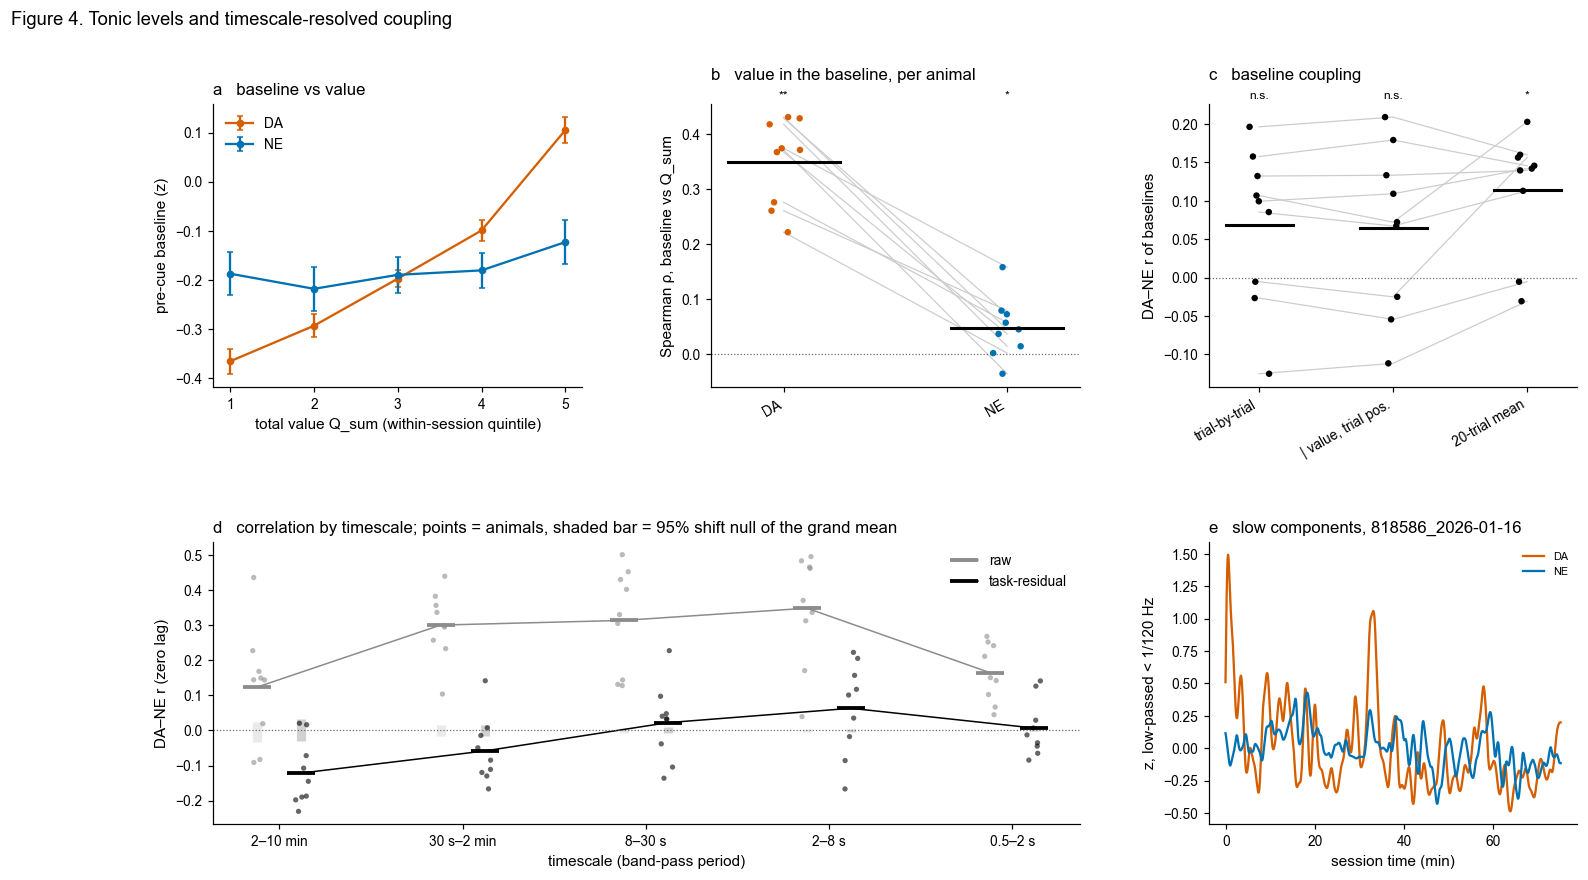

In [26]:
fig = plt.figure(figsize=(16, 8.5))
gs = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
for sig in ("da", "ne"):
    c = q_curve[f"{sig}_pre"].unstack("q_bin")
    m_, se = c.mean(0), c.std(0) / np.sqrt(len(c))
    ax.errorbar(np.arange(5) + 1, m_, se, color=SIG_COLOR[sig], marker="o", ms=4, capsize=2,
                label=sig.upper())
ax.set_xlabel("total value Q_sum (within-session quintile)")
ax.set_ylabel("pre-cue baseline (z)")
ax.set_title("a   baseline vs value", loc="left")
ax.legend()
style_ax(ax)

ax = fig.add_subplot(gs[0, 1])
animal_strip(ax, bl_animal, ["da_value", "ne_value"], ["DA", "NE"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "Spearman ρ, baseline vs Q_sum",
             title="b   value in the baseline, per animal")

ax = fig.add_subplot(gs[0, 2])
animal_strip(ax, bl_animal, ["r_raw", "r_resid", "r_slow"],
             ["trial-by-trial", "| value, trial pos.", f"{BL_WINDOW}-trial mean"],
             ["k", "k", "k"], "DA–NE r of baselines", title="c   baseline coupling")

ax = fig.add_subplot(gs[1, :2])
x = np.arange(len(BANDS))
for arr, nul, col, lab, dx in ((band_raw, gm_null_raw, "0.55", "raw", -0.12),
                               (band_res, gm_null_res, "k", "task-residual", 0.12)):
    for k in range(len(BANDS)):
        ax.scatter(np.full(len(arr), x[k] + dx) + (rng.random(len(arr)) - 0.5) * 0.08, arr[:, k],
                   s=12, color=col, alpha=0.6, edgecolor="none")
        lo, hi = np.percentile(nul[k], [2.5, 97.5])
        ax.plot([x[k] + dx] * 2, [lo, hi], color=col, lw=6, alpha=0.18, solid_capstyle="butt")
    ax.plot(x + dx, arr.mean(0), color=col, marker="_", ms=18, mew=2.5, ls="-", lw=1, label=lab)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_xticks(x)
ax.set_xticklabels(BAND_NAMES)
ax.set_xlabel("timescale (band-pass period)")
ax.set_ylabel("DA–NE r (zero lag)")
ax.set_title("d   correlation by timescale; points = animals, shaded bar = 95% shift null of the "
             "grand mean", loc="left")
ax.legend()
style_ax(ax)

ax = fig.add_subplot(gs[1, 2])
from scipy import signal as sps
sos = sps.butter(2, 1 / 120, btype="low", fs=FS, output="sos")
t_min = (ex["t0"] + np.arange(len(ex["da"])) / FS) / 60
for sig in ("da", "ne"):
    ax.plot(t_min, sps.sosfiltfilt(sos, fc.zscore(ex[sig])), color=SIG_COLOR[sig], label=sig.upper())
tr = ex["trials"]
ax.set_xlabel("session time (min)")
ax.set_ylabel("z, low-passed < 1/120 Hz")
ax.set_title(f"e   slow components, {ex['session']}", loc="left")
ax.legend(fontsize=7)
style_ax(ax)
fig.suptitle("Figure 4. Tonic levels and timescale-resolved coupling", x=0.01, ha="left")
save_fig(fig, "fip_05_fig4_tonic", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. How often does one signal have a large transient without the other?

A transient is **large** at prominence ≥ `LARGE_PROM` z in its own signal. It is **solo** if the
other signal has no transient of even `PARTNER_PROM` z within ±`MATCH_WIN_S` s. Using a lower bar
for the partner than for the event keeps a transient from being called solo because the other
signal's co-transient happened to fall just below the "large" threshold.

Chance is the matched fraction when the other signal's transient train is circularly shifted
(same rates and clustering, alignment removed). The **chance-corrected coupling** is
`(observed − chance) / (1 − chance)`: 0 means the two trains are aligned no more than chance, 1
means every large transient has a partner. The shift also removes shared task timing, so this null
tests alignment beyond event rates, not beyond shared task drive; the context split in panel e
addresses that.

In [27]:
paired["solo"] = ~paired["matched"]
rows = []
for (subj, sess, sig), g in paired.groupby(["subject", "session", "sig"]):
    matched = g["matched"].mean()
    chance = g["null_frac"].iloc[0]
    rows.append(dict(subject=subj, session=sess, sig=sig,
                     rate_per_min=len(g) / g["dur"].iloc[0] * 60,
                     solo_frac=1 - matched, chance_solo=1 - chance,
                     coupling=(matched - chance) / (1 - chance)))
solo_sess = pd.DataFrame(rows)
solo_animal = solo_sess.groupby(["subject", "sig"])[["rate_per_min", "solo_frac", "chance_solo",
                                                      "coupling"]].mean().unstack("sig")
solo_animal.columns = [f"{a}_{b}" for a, b in solo_animal.columns]
summary = []
for c in solo_animal:
    m, p, n = fc.wilcoxon_animals(solo_animal[c])
    summary.append(dict(measure=c, mean=m, p_vs_0=p))
d = solo_animal["coupling_da"] - solo_animal["coupling_ne"]
print("coupling DA→NE minus NE→DA: mean %+.3f, Wilcoxon p = %.4f" % (d.mean(), fc.wilcoxon_animals(d)[1]))
pd.DataFrame(summary).set_index("measure").round(3)

coupling DA→NE minus NE→DA: mean +0.292, Wilcoxon p = 0.0039


,mean,p_vs_0
measure,,
rate_per_min_da,8.722,0.004
rate_per_min_ne,20.315,0.004
solo_frac_da,0.174,0.004
solo_frac_ne,0.551,0.004
chance_solo_da,0.367,0.004
chance_solo_ne,0.718,0.004
coupling_da,0.519,0.004
coupling_ne,0.227,0.004


In [28]:
# Solo fraction as a function of transient size, and threshold sensitivity.
PROM_BINS = [2.0, 2.5, 3.0, 4.0, np.inf]
paired["prom_bin"] = pd.cut(paired["prominence"], PROM_BINS, right=False)
size_curve = (paired.groupby(["subject", "sig", "prom_bin"], observed=True)["solo"].mean()
              .unstack("prom_bin"))

sweep = []
for thr in PROM_SWEEP:
    for p in pairs:
        det = {s: fc.detect_transients(fc.zscore(p[s]), FS, prominence=min(thr, PARTNER_PROM))
               for s in ("da", "ne")}
        for s, o in (("da", "ne"), ("ne", "da")):
            big = det[s][det[s]["prominence"] >= thr]
            _, lag = fc.nearest_partner(big["i"].to_numpy() / FS, det[o]["i"].to_numpy() / FS)
            sweep.append(dict(thr=thr, subject=p["subject"], session=p["session"], sig=s,
                              solo=np.mean(np.abs(lag) > MATCH_WIN_S) if len(big) else np.nan,
                              rate=len(big) / (len(p["da"]) / FS) * 60))
sweep = (pd.DataFrame(sweep).groupby(["thr", "subject", "sig"])[["solo", "rate"]].mean()
         .groupby(level=["thr", "sig"]).agg(["mean", "sem"]))
sweep.round(3)

solo           rate       
          mean    sem    mean    sem
thr sig                             
1.5 da   0.197  0.029  11.850  0.973
    ne   0.605  0.020  29.469  2.525
2.0 da   0.174  0.027   8.722  0.659
    ne   0.551  0.020  20.315  1.633
2.5 da   0.157  0.024   6.612  0.532
    ne   0.494  0.023  13.993  1.112
3.0 da   0.145  0.022   5.063  0.450
    ne   0.447  0.029   9.592  0.830

In [29]:
# Context composition of solo and coincident events, and event-triggered traces.
ctx_tab = (paired.groupby(["subject", "sig", "solo"])["context"].value_counts(normalize=True)
           .unstack("context").fillna(0).groupby(level=["sig", "solo"]).mean())
ctx_tab = ctx_tab[[c for c in CONTEXTS if c in ctx_tab]]
solo_by_ctx = (paired.groupby(["subject", "sig", "context"])["solo"].mean()
               .unstack("context").groupby(level="sig").mean())[ctx_tab.columns]
print("fraction of large transients that are solo, by context (mean over animals):")
print(solo_by_ctx.round(2).to_string())
print("\nwhere solo events happen (share of each signal's solo events by context):")
print(ctx_tab.xs(True, level="solo").round(2).to_string())

ETA_LAGS = np.arange(-2.0, 3.0 + 1e-9, 1 / FS)
eta = {}
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        z = {s: fc.zscore(p[s]) for s in ("da", "ne")}
        g = paired[paired.session == p["session"]]
        for s in ("da", "ne"):
            for solo in (True, False):
                t = g[(g.sig == s) & (g.solo == solo)]["t"].to_numpy()
                if len(t) < 3:
                    continue
                for o in ("da", "ne"):
                    acc.setdefault((s, solo, o), []).append(
                        np.nanmean(fc.peri_event(z[o], p["t0"], FS, t, ETA_LAGS), 0))
    for k, v in acc.items():
        eta.setdefault(k, []).append(np.mean(v, 0))

fraction of large transients that are solo, by context (mean over animals):
context  rewarded  unrewarded  cue, no response  licking  quiet
sig                                                            
da           0.10        0.09              0.16     0.21   0.30
ne           0.18        0.26              0.44     0.57   0.76

where solo events happen (share of each signal's solo events by context):
context  rewarded  unrewarded  cue, no response  licking  quiet
sig                                                            
da           0.19        0.09              0.03     0.33   0.37
ne           0.04        0.07              0.01     0.24   0.64


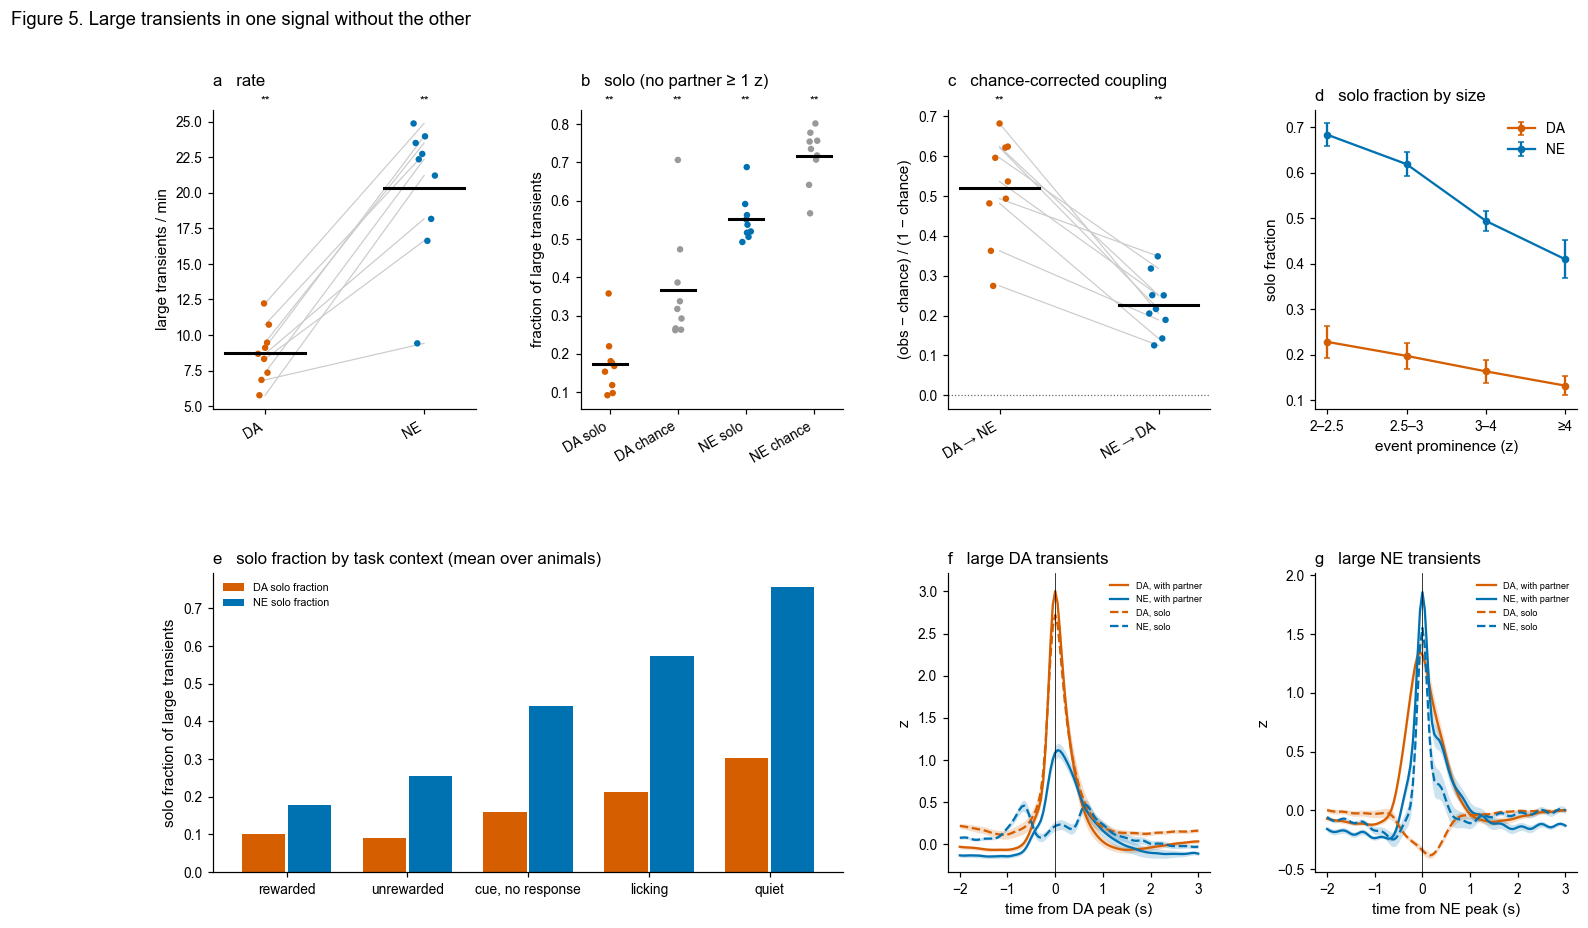

In [30]:
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.4)

ax = fig.add_subplot(gs[0, 0])
animal_strip(ax, solo_animal, ["rate_per_min_da", "rate_per_min_ne"], ["DA", "NE"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "large transients / min",
             title="a   rate", zero=False)

ax = fig.add_subplot(gs[0, 1])
cols = ["solo_frac_da", "chance_solo_da", "solo_frac_ne", "chance_solo_ne"]
animal_strip(ax, solo_animal, cols, ["DA solo", "DA chance", "NE solo", "NE chance"],
             [SIG_COLOR["da"], "0.6", SIG_COLOR["ne"], "0.6"], "fraction of large transients",
             title="b   solo (no partner ≥ %.0f z)" % PARTNER_PROM, zero=False, connect=False)

ax = fig.add_subplot(gs[0, 2])
animal_strip(ax, solo_animal, ["coupling_da", "coupling_ne"], ["DA → NE", "NE → DA"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "(obs − chance) / (1 − chance)",
             title="c   chance-corrected coupling")

ax = fig.add_subplot(gs[0, 3])
x = np.arange(len(PROM_BINS) - 1)
for s in ("da", "ne"):
    c = size_curve.xs(s, level="sig")
    ax.errorbar(x, c.mean(0), c.std(0) / np.sqrt(c.notna().sum(0)), color=SIG_COLOR[s],
                marker="o", ms=4, capsize=2, label=s.upper())
ax.set_xticks(x)
ax.set_xticklabels(["2–2.5", "2.5–3", "3–4", "≥4"])
ax.set_xlabel("event prominence (z)")
ax.set_ylabel("solo fraction")
ax.set_title("d   solo fraction by size", loc="left")
ax.legend()
style_ax(ax)

ax = fig.add_subplot(gs[1, 0:2])
xx = np.arange(len(ctx_tab.columns))
for k, s in enumerate(("da", "ne")):
    ax.bar(xx + (k - 0.5) * 0.38, solo_by_ctx.loc[s], width=0.36, color=SIG_COLOR[s],
           label=f"{s.upper()} solo fraction")
ax.set_xticks(xx)
ax.set_xticklabels(ctx_tab.columns)
ax.set_ylabel("solo fraction of large transients")
ax.set_title("e   solo fraction by task context (mean over animals)", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

for k, (s, title) in enumerate((("da", "f   large DA transients"), ("ne", "g   large NE transients"))):
    ax = fig.add_subplot(gs[1, 2 + k])
    for solo, ls in ((False, "-"), (True, "--")):
        for o in ("da", "ne"):
            if (s, solo, o) in eta:
                grand_trace(ax, eta[(s, solo, o)], ETA_LAGS, SIG_COLOR[o],
                            f"{o.upper()}, {'solo' if solo else 'with partner'}", ls=ls)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(f"time from {s.upper()} peak (s)")
    ax.set_ylabel("z")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=6)
    style_ax(ax)
fig.suptitle("Figure 5. Large transients in one signal without the other", x=0.01, ha="left")
save_fig(fig, "fip_05_fig5_dissociation", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Summary

One row per question, each number a mean over animals with its Wilcoxon p against zero.

In [31]:
def row(q, measure, values):
    m, p, n = fc.wilcoxon_animals(values)
    v = np.asarray(values, float)
    return dict(question=q, measure=measure, mean=round(m, 3), p=round(p, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")

g_da = rpe_animal.xs(("da", "full"), level=["sig", "window"])
g_ne = rpe_animal.xs(("ne", "full"), level=["sig", "window"])
S = [
    row("1 RPE coding", "DA reward term (z)", g_da["reward"]),
    row("1 RPE coding", "DA RPE slope | rewarded, 0–2 s", g_da["rpe_rew"]),
    row("1 RPE coding", "DA RPE slope | unrewarded, 0–2 s", g_da["rpe_unrew"]),
    row("1 RPE coding", "NE reward term (z)", g_ne["reward"]),
    row("1 RPE coding", "NE RPE slope | rewarded, 0–2 s", g_ne["rpe_rew"]),
    row("1 RPE coding", "NE RPE slope | unrewarded, 0–2 s", g_ne["rpe_unrew"]),
    row("1 tuning", "trial-level r of outcome + RPE predictions", tuning_trial_animal["full"]),
    row("2 trial coupling", "total r, outcome response", resp_corr_animal["total_full"]),
    row("2 trial coupling", "within rewarded r", resp_corr_animal["rewarded_full"]),
    row("2 trial coupling", "within unrewarded r", resp_corr_animal["unrewarded_full"]),
    row("2 trial coupling", "residual r after outcome + RPE", resp_corr_animal["residual_full"]),
    *[row("2b controls", f"residual r, {n}", ctrl_corr_animal[f"{n}|full"]) for n in CONTROLS if n != "outcome + RPE"],
    row("3 timing", "NE − DA peak latency after cue (s)", lat_animal["ne_minus_da"]),
    row("3 timing", "trial latency ρ, RT partialled", lat_animal["r_lat_partial"]),
    row("3 timing", "transient lag, centre of excess (s)", peak_lag_animal),
]
for c in amp.columns:
    S.append(row("3 magnitude", f"matched-pair amplitude ρ, {c}", amp[c]))
S += [
    row("4 tonic", "DA baseline vs value ρ", bl_animal["da_value"]),
    row("4 tonic", "NE baseline vs value ρ", bl_animal["ne_value"]),
    row("4 tonic", "baseline r, trial-by-trial", bl_animal["r_raw"]),
    row("4 tonic", f"baseline r, {BL_WINDOW}-trial mean", bl_animal["r_slow"]),
    row("4 tonic", "continuous r, raw", whole["r_all_raw"]),
    row("4 tonic", "continuous r, task-residual", whole["r_all_res"]),
]
for k, nm in enumerate(BAND_NAMES):
    S.append(row("4 timescale", f"raw r, {nm}", band_raw[:, k]))
    S.append(row("4 timescale", f"residual r, {nm}", band_res[:, k]))
S += [
    row("5 dissociation", "DA solo fraction", solo_animal["solo_frac_da"]),
    row("5 dissociation", "NE solo fraction", solo_animal["solo_frac_ne"]),
    row("5 dissociation", "DA→NE chance-corrected coupling", solo_animal["coupling_da"]),
    row("5 dissociation", "NE→DA chance-corrected coupling", solo_animal["coupling_ne"]),
]
summary_tbl = pd.DataFrame(S).set_index(["question", "measure"])
summary_tbl

mean       p animals_positive
question         measure                                                                   
1 RPE coding     DA reward term (z)                          1.034  0.0039              9/9
                 DA RPE slope | rewarded, 0–2 s              0.096  0.4258              5/9
                 DA RPE slope | unrewarded, 0–2 s            0.438  0.0039              9/9
                 NE reward term (z)                          0.234  0.0078              8/9
                 NE RPE slope | rewarded, 0–2 s              0.295  0.0039              9/9
                 NE RPE slope | unrewarded, 0–2 s            0.153  0.0547              8/9
1 tuning         trial-level r of outcome + RPE predictions  0.894  0.0039              9/9
2 trial coupling total r, outcome response                   0.313  0.0039              9/9
                 within rewarded r                           0.144  0.0195              8/9
                 within unrewarded r                         0.124  0.0547              7/9
                 residual r after outcome + RPE              0.131  0.0273              8/9
2b controls      residual r, + response time                 0.135  0.0273              8/9
                 residual r, + trial position                0.139  0.0273              8/9
                 residual r, + both baselines                0.118  0.0391              8/9
3 timing         NE − DA peak latency after cue (s)          0.198  0.0039              9/9
                 trial latency ρ, RT partialled              0.212  0.0039              9/9
                 transient lag, centre of excess (s)         0.084  0.0039              9/9
3 magnitude      matched-pair amplitude ρ, rewarded          0.106  0.0039              9/9
                 matched-pair amplitude ρ, unrewarded        0.058  0.0977              8/9
                 matched-pair amplitude ρ, cue, no response -0.004  1.0000              4/8
                 matched-pair amplitude ρ, licking           0.065  0.0977              6/9
                 matched-pair amplitude ρ, quiet             0.130  0.0039              9/9
4 tonic          DA baseline vs value ρ                      0.350  0.0039              9/9
                 NE baseline vs value ρ                      0.047  0.0195              8/9
                 baseline r, trial-by-trial                  0.069  0.1289              6/9
                 baseline r, 20-trial mean                   0.114  0.0195              7/9
                 continuous r, raw                           0.260  0.0039              9/9
                 continuous r, task-residual                 0.025  0.4961              6/9
4 timescale      raw r, 2–10 min                             0.124  0.0391              7/9
                 residual r, 2–10 min                       -0.121  0.0195              2/9
                 raw r, 30 s–2 min                           0.300  0.0039              9/9
                 residual r, 30 s–2 min                     -0.058  0.1289              2/9
                 raw r, 8–30 s                               0.314  0.0039              9/9
                 residual r, 8–30 s                          0.022  0.6523              6/9
                 raw r, 2–8 s                                0.349  0.0039              9/9
                 residual r, 2–8 s                           0.063  0.2031              6/9
                 raw r, 0.5–2 s                              0.165  0.0039              9/9
                 residual r, 0.5–2 s                         0.007  0.9102              4/9
5 dissociation   DA solo fraction                            0.174  0.0039              9/9
                 NE solo fraction                            0.551  0.0039              9/9
                 DA→NE chance-corrected coupling             0.519  0.0039              9/9
                 NE→DA chance-corrected coupling             0.227  0.0039              9/9

### What these measurements support

*(Written against the local run of 2026-09-28; re-check the numbers above after any re-run.)*

**1. NE carries a robust signed RPE late in its outcome response. For DA, within-outcome RPE
scaling cannot be separated from its value-tracking baseline in these data.** RPE is `RPE_earned`
(Rachel's convention), trials with extra water are excluded, and response time and trial position
are nuisance terms.

- *NE.* The first 0.5 s after the outcome is the same size after rewards and omissions
  (reward term ≈ 0), but the reward response already scales with RPE there: +0.25 with the
  baseline subtracted and +0.19 with it as a covariate, 9/9 animals both ways. From 0.75 to 2 s
  it scales more strongly (+0.33 and +0.27, 9/9). The late omission response scales the same way
  with the baseline subtracted (+0.19, 8/9, p = 0.039) and trends with it as a covariate (+0.12,
  6/9). NE's baseline hardly tracks value, so the baseline choice barely matters for NE.
- *DA.* The reward term is large (≈1.0 z, 9/9) and the omission dip is clear (Fig 1a). With the
  baseline subtracted, the early reward response scales with RPE (+0.35, 8/9) and the late
  omission dip does too (+0.52, 9/9). With the baseline as a covariate, both effects vanish
  (−0.00 and +0.07), and the late reward response scales *negatively* with RPE (−0.45, 0/9
  positive). DA's pre-trial level tracks value (ρ = 0.35), and within an outcome RPE is value with
  the sign flipped, so the two are nearly collinear and the data cannot say which one DA's
  outcome response follows.
- *Tuning similarity (Fig 1c).* Across trials, the two signals' outcome + RPE predictions
  correlate at r = 0.89 (0–2 s; 0.58 in the first 0.5 s, where DA's reward term is large and
  NE's is zero). Within an animal, sessions where DA's coefficient is larger have a slightly
  larger NE coefficient (ρ = 0.23 reward, 0.23 RPE | rewarded, 0.31 RPE | unrewarded). Across
  the 9 animal means none of the three correlates (|ρ| ≤ 0.38, p ≥ 0.3).
- *Three artifacts removed along the way.* With `RPE_all`, the ~1% of trials with extra water
  (RPE up to 2, double-water responses) had enough leverage to produce a positive DA RPE slope
  (+0.44) that disappears without them. Without a response-time term, the window just before the
  outcome showed an RPE-signed coefficient in both signals: low-value choices are slower, so more
  of the cue response falls before the outcome. Two sessions whose Q-learning fit leaves RPE
  nearly constant within each outcome (SD ≈ 0.01) gave RPE slopes of ±10–16, which pulled their
  animals' means and made DA's and NE's coefficients look anticorrelated across sessions
  (r ≈ −0.8); they are excluded.

**2. Outcome responses covary through the shared outcome effect plus a smaller shared residual.**
Across trials, DA and NE outcome responses correlate at r = 0.31. Within rewarded trials r = 0.14
(8/9 animals) and within unrewarded 0.12 (7/9, p = 0.055), so about half of the total comes from
both signals being higher after rewards. After outcome and RPE are regressed out, the residuals
correlate at r = 0.13 (8/9, p = 0.027), about equally in the early (0.14) and late (0.13) windows:
on a given trial, a larger DA response than outcome and RPE predict tends to come with a larger
NE response. Adding response time (0.135), trial position (0.14) or both pre-cue baselines
(0.12) to the model, one at a time, changes the residual r by at most 0.02 (none significant), so
it is not produced by response timing, drift across the session or the baseline subtraction.

**3. Phasic events are co-timed, NE ≈ 0.2 s later, and weakly co-scaled.** Task-locked, NE peaks
196 ms after DA in every animal. Trial-to-trial peak latencies correlate (ρ = 0.21) independently
of response time. Across all large DA transients, the above-chance NE partners sit between 0 and
+0.3 s, centred at +0.09 s (9/9 animals). Among matched pairs, amplitudes correlate only weakly: ρ ≈ 0.11 after rewards and 0.13 in
quiet periods, and ≈ 0 for cue responses on ignored trials. Coincidence in time is much stronger
than coupling in size. The kinetics caveat below applies to every lag here.

**4. Tonic levels are not shared: value is in DA's baseline only, and the slow coupling is task
drive.** DA's pre-cue baseline tracks total value (ρ = 0.35, 9/9 animals); NE's barely does
(ρ = 0.05). Trial-by-trial baselines correlate at r = 0.07 (n.s.), and 20-trial running means at
0.11. The continuous DA–NE correlation (r = 0.26) falls to 0.025 once the average task-evoked
responses are removed, and this holds at every timescale from 0.5 s to 2 min. The raw coupling at
30 s–2 min (r = 0.30) is therefore inherited from both signals following the same task events and
their slowly varying rate. At 2–10 min the residual correlation turns negative (−0.12, 7/9
animals). That residual is a partial correlation given task-event timing: the two signals
co-fluctuate slightly *less* than their common dependence on event density predicts. It is not
evidence for an opposing tonic process without an explicit model of engagement.

**5. Dissociation is asymmetric: DA transients almost always come with NE, NE transients often come
alone.** NE has 2.3× as many large transients (20 vs 9 per min). 17% of large DA transients have
no NE partner (chance 37%), against 55% of large NE transients with no DA partner (chance 72%).
Chance-corrected coupling is 0.52 from DA to NE and 0.23 from NE to DA. Solo NE transients happen
mostly outside the outcome window: 76% of NE transients in quiet periods and 57% during licking
are solo, against 18% after rewards. Larger NE transients are less often solo, but 41% of those
≥ 4 z still are. Around solo NE transients DA dips slightly. Part of that dip is selection, since
solo is defined by the absence of a DA peak.

**Overall.** DA and NE share one outcome-locked phasic component: both respond more to rewards
than omissions, they are co-timed within ~0.1–0.2 s, and their outcome responses share
trial-to-trial variability beyond outcome and RPE (residual r ≈ 0.13). An RPE-scaled component is
clear in NE's reward response, early and late. In DA it cannot be
separated from the value signal in DA's own baseline at these response times. The signals separate
in three places. NE has a large outcome-independent response. NE fires many transients outside the
outcome that DA does not join. Only DA carries a tonic value signal.

### Caveats

- **Indicator kinetics.** dLight and axonal GCaMP rise and decay at different rates, so the
  latency and lag measurements describe the recorded signals. They do not establish which
  transmitter leads.
- **What NE is.** Axonal calcium in LC terminals in PL, not NE release. DA is extracellular DA at
  one NAc site. A correlation bounds how tightly LC-axon activity and NAc DA co-vary.
- **Behavior model.** RPE (`RPE_earned`) and value are from the per-session Q-learning fit the asset carries.
  Any misfit leaves RPE-related variance in the section 2 residuals, which would inflate the
  residual correlation, not create the difference between DA and NE.
- **Transients.** Detected on z-scored dF/F, so "large" is relative to each signal's own variance
  in that session. Panel 5d and the threshold sweep show how the solo fractions depend on that
  choice.
- **Scope.** One hemisphere per animal, and side differs between animals. The two assets differ in
  curation pass and animals, so asset is confounded with animal. 816212 is an outlier in every
  coupling measure (near-zero or negative); it is kept, and animal-level tests are rank-based.
- **Figures** go to `FIG_DIR`, which on Code Ocean is scratch and not preserved by a reproducible
  run. Copy paper figures to `/results`.